# WiFiVision — Experiment C: Richer Spatial CNN

**Goal:** test whether preserving more CSI spatial/subcarrier structure improves the amplitude-only baseline.

- Input: `(B, 30, 3, 114, 10)`
- Output: `(B, 17, 2)`
- Input representation: **amplitude only**
- Subjects: train `1–7`, validation `8`, test `9–10`
- Window: `30` frames
- Stride: `15` frames
- Loss: MSE
- Optimizer: Adam, `lr=1e-3`
- Early stopping: patience `5`
- Epochs: maximum `30`

This experiment changes the **spatial CNN only**. Phase is intentionally excluded because the previous phase-enhanced ablation performed worse than the amplitude-only baseline.


In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Reproducibility for this experiment
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.10.0+cpu
CUDA available: False


In [2]:
# ============================================================
# PROJECT PATHS
# ============================================================

ROOT = r"C:\Users\ROHITH KANNA S\WiFiVision"

SEQ_DIR = os.path.join(
    ROOT,
    "data",
    "processed",
    "mmfi_sequence"
)

CSI_DIR = os.path.join(
    ROOT,
    "data",
    "processed",
    "mmfi_calibrated"
)

MODEL_DIR = os.path.join(
    ROOT,
    "models"
)

os.makedirs(MODEL_DIR, exist_ok=True)

print("ROOT:", ROOT)
print("Sequence data:", SEQ_DIR)
print("CSI data:", CSI_DIR)
print("Model directory:", MODEL_DIR)

ROOT: C:\Users\ROHITH KANNA S\WiFiVision
Sequence data: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\mmfi_sequence
CSI data: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\mmfi_calibrated
Model directory: C:\Users\ROHITH KANNA S\WiFiVision\models


In [3]:
# ============================================================
# CHECK REQUIRED FILES
# ============================================================

required_files = {
    "amplitude_clean.npy": os.path.join(CSI_DIR, "amplitude_clean.npy"),
    "pose.npy": os.path.join(SEQ_DIR, "pose.npy"),
    "subject.npy": os.path.join(SEQ_DIR, "subject.npy"),
    "action.npy": os.path.join(SEQ_DIR, "action.npy"),
}

for name, path in required_files.items():
    print(f"{name:20s} ->", "FOUND" if os.path.exists(path) else "MISSING")

missing = [
    path for path in required_files.values()
    if not os.path.exists(path)
]

if missing:
    raise FileNotFoundError(
        "Required files are missing:\n" +
        "\n".join(missing)
    )

amplitude_clean.npy  -> FOUND
pose.npy             -> FOUND
subject.npy          -> FOUND
action.npy           -> FOUND


In [4]:
# ============================================================
# LOAD DATA
# ============================================================

# Clean/repaired amplitude from the calibration stage.
# Shape: (270, 297, 3, 114, 10)
amplitude = np.load(
    required_files["amplitude_clean.npy"],
    mmap_mode="r"
)

# Ground-truth pose.
# Shape: (270, 297, 17, 2)
pose = np.load(
    required_files["pose.npy"],
    mmap_mode="r"
)

subject = np.load(
    required_files["subject.npy"]
)

action = np.load(
    required_files["action.npy"]
)

print("Amplitude:", amplitude.shape, amplitude.dtype)
print("Pose     :", pose.shape, pose.dtype)
print("Subject  :", subject.shape, np.unique(subject))
print("Action   :", action.shape, np.unique(action))

Amplitude: (270, 297, 3, 114, 10) float32
Pose     : (270, 297, 17, 2) float32
Subject  : (270,) [ 1  2  3  4  5  6  7  8  9 10]
Action   : (270,) [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27]


In [5]:
# ============================================================
# DATA SANITY CHECK
# ============================================================

assert amplitude.shape == (270, 297, 3, 114, 10)
assert pose.shape == (270, 297, 17, 2)

assert np.isfinite(amplitude).all(), "Amplitude contains NaN/Inf"
assert np.isfinite(pose).all(), "Pose contains NaN/Inf"

print("Amplitude range:", float(amplitude.min()), "to", float(amplitude.max()))
print("Pose range:", float(pose.min()), "to", float(pose.max()))
print("All loaded values are finite.")

Amplitude range: 0.0 to 56.747005462646484
Pose range: -1.4271228313446045 to 2.7987332344055176
All loaded values are finite.


## 1. Subject-independent split

We must split by **subject**, not randomly by windows. Otherwise windows from the same person can appear in both training and test data, causing subject leakage.

Current protocol:

- Train: S01–S07
- Validation: S08
- Test: S09–S10


In [6]:
# ============================================================
# SUBJECT SPLIT
# ============================================================

TRAIN_SUBJECTS = np.arange(1, 8)
VAL_SUBJECTS = np.array([8])
TEST_SUBJECTS = np.array([9, 10])

train_seq = np.where(
    np.isin(subject, TRAIN_SUBJECTS)
)[0]

val_seq = np.where(
    np.isin(subject, VAL_SUBJECTS)
)[0]

test_seq = np.where(
    np.isin(subject, TEST_SUBJECTS)
)[0]

print("Train subjects:", TRAIN_SUBJECTS)
print("Validation subjects:", VAL_SUBJECTS)
print("Test subjects:", TEST_SUBJECTS)

print()
print("Training sequences:", len(train_seq))
print("Validation sequences:", len(val_seq))
print("Test sequences:", len(test_seq))

assert len(train_seq) == 189
assert len(val_seq) == 27
assert len(test_seq) == 54

Train subjects: [1 2 3 4 5 6 7]
Validation subjects: [8]
Test subjects: [ 9 10]

Training sequences: 189
Validation sequences: 27
Test sequences: 54


## 2. Pose normalization

Normalization statistics are calculated **only from training sequences**.

For each of the 17 joints and both coordinates:

`z = (x - training_mean) / training_std`

The validation and test sets use the same training statistics.


In [7]:
# ============================================================
# POSE NORMALIZATION — TRAINING DATA ONLY
# ============================================================

pose_train = np.asarray(
    pose[train_seq],
    dtype=np.float32
)

pose_mean = pose_train.mean(
    axis=(0, 1)
)

pose_std = pose_train.std(
    axis=(0, 1)
)

# Protect against a zero standard deviation.
pose_std = np.maximum(
    pose_std,
    1e-6
)

print("Mean shape:", pose_mean.shape)
print("Std shape :", pose_std.shape)

print()
print("X mean range:",
      float(pose_mean[:, 0].min()),
      "to",
      float(pose_mean[:, 0].max()))

print("Y mean range:",
      float(pose_mean[:, 1].min()),
      "to",
      float(pose_mean[:, 1].max()))

print()
print("X std range:",
      float(pose_std[:, 0].min()),
      "to",
      float(pose_std[:, 0].max()))

print("Y std range:",
      float(pose_std[:, 1].min()),
      "to",
      float(pose_std[:, 1].max()))

Mean shape: (17, 2)
Std shape : (17, 2)

X mean range: -0.3496984839439392 to 0.16144020855426788
Y mean range: -0.6715198159217834 to 0.7596257925033569

X std range: 0.11285988241434097 to 0.21926693618297577
Y std range: 0.04630732163786888 to 0.31275475025177


In [8]:
# ============================================================
# NORMALIZATION ROUND-TRIP CHECK
# ============================================================

sample_pose = np.asarray(
    pose_train[0, 0],
    dtype=np.float32
)

normalized = (
    sample_pose - pose_mean
) / pose_std

reconstructed = (
    normalized * pose_std
) + pose_mean

print(
    "Maximum reconstruction error:",
    np.max(np.abs(
        reconstructed - sample_pose
    ))
)

Maximum reconstruction error: 1.4901161e-08


## 3. Temporal window dataset

Each sequence has 297 frames.

With:

- window length = 30
- stride = 15

each sequence produces:

`floor((297 - 30) / 15) + 1 = 18 windows`

Therefore:

- train: `189 × 18 = 3402`
- validation: `27 × 18 = 486`
- test: `54 × 18 = 972`

The target is the pose at the **last frame of each 30-frame window**.


In [9]:
# ============================================================
# WINDOW CONFIGURATION
# ============================================================

WINDOW = 30
STRIDE = 15

windows_per_sequence = (
    (297 - WINDOW) // STRIDE
) + 1

print("Window length:", WINDOW)
print("Stride:", STRIDE)
print("Windows per sequence:", windows_per_sequence)

assert windows_per_sequence == 18

Window length: 30
Stride: 15
Windows per sequence: 18


In [10]:
# ============================================================
# AMPLITUDE-ONLY DATASET
# ============================================================

class AmplitudeDataset(Dataset):

    def __init__(
        self,
        sequence_indices
    ):

        self.sequence_indices = np.asarray(
            sequence_indices,
            dtype=np.int64
        )

        self.windows = []

        for seq in self.sequence_indices:

            for start in range(
                0,
                297 - WINDOW + 1,
                STRIDE
            ):

                self.windows.append(
                    (
                        int(seq),
                        int(start)
                    )
                )

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, index):

        seq, start = self.windows[index]

        end = start + WINDOW

        # ----------------------------------------------------
        # CSI
        #
        # (30, 3, 114, 10)
        # ----------------------------------------------------

        x = np.asarray(
            amplitude[
                seq,
                start:end
            ],
            dtype=np.float32
        )

        # ----------------------------------------------------
        # TARGET = LAST FRAME OF WINDOW
        #
        # (17, 2)
        # ----------------------------------------------------

        target_frame = end - 1

        y = np.asarray(
            pose[
                seq,
                target_frame
            ],
            dtype=np.float32
        )

        # Normalize using TRAINING statistics.
        y = (
            y - pose_mean
        ) / pose_std

        return (
            torch.from_numpy(x.copy()),
            torch.from_numpy(y.copy())
        )


amp_train_dataset = AmplitudeDataset(train_seq)
amp_val_dataset = AmplitudeDataset(val_seq)
amp_test_dataset = AmplitudeDataset(test_seq)

print("Train windows:", len(amp_train_dataset))
print("Validation windows:", len(amp_val_dataset))
print("Test windows:", len(amp_test_dataset))

assert len(amp_train_dataset) == 3402
assert len(amp_val_dataset) == 486
assert len(amp_test_dataset) == 972

Train windows: 3402
Validation windows: 486
Test windows: 972


In [11]:
# ============================================================
# VERIFY ONE SAMPLE
# ============================================================

sample_x, sample_y = amp_train_dataset[0]

print("Sample CSI shape:", tuple(sample_x.shape))
print("Sample pose shape:", tuple(sample_y.shape))
print("CSI dtype:", sample_x.dtype)
print("Pose dtype:", sample_y.dtype)

assert tuple(sample_x.shape) == (30, 3, 114, 10)
assert tuple(sample_y.shape) == (17, 2)

Sample CSI shape: (30, 3, 114, 10)
Sample pose shape: (17, 2)
CSI dtype: torch.float32
Pose dtype: torch.float32


In [12]:
# ============================================================
# DATALOADERS
# ============================================================

BATCH_SIZE = 8

train_loader = DataLoader(
    amp_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    amp_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    amp_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

x_batch, y_batch = next(iter(train_loader))

print("Batch CSI :", tuple(x_batch.shape))
print("Batch pose:", tuple(y_batch.shape))

assert tuple(x_batch.shape) == (8, 30, 3, 114, 10)
assert tuple(y_batch.shape) == (8, 17, 2)

Batch CSI : (8, 30, 3, 114, 10)
Batch pose: (8, 17, 2)


## 4. Experiment C model — richer spatial CNN

The previous baseline aggressively compressed each frame using global `1×1` pooling.

Experiment C retains a `4×2` spatial feature map before projection:

`3 × 114 × 10 → CNN → 64 × 4 × 2 → 64-D frame feature → GRU → pose`

Only the spatial encoder is changed. The input remains amplitude-only.


In [13]:
# ============================================================
# RICHER SPATIAL CNN
# ============================================================

class SpatialFrameCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                3,
                16,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(),

            # Preserve spatial structure
            nn.AdaptiveAvgPool2d(
                (4, 2)
            )
        )

        self.projection = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                64 * 4 * 2,
                64
            ),

            nn.ReLU()
        )

    def forward(self, x):

        x = self.features(x)

        x = self.projection(x)

        return x


class SpatialCSI2Pose(nn.Module):

    def __init__(self):

        super().__init__()

        self.frame_cnn = SpatialFrameCNN()

        self.gru = nn.GRU(
            input_size=64,
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )

        self.head = nn.Sequential(

            nn.Linear(
                64,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                34
            )
        )

    def forward(self, x):

        batch_size = x.shape[0]
        sequence_length = x.shape[1]

        # (B, 30, 3, 114, 10)
        x = x.reshape(
            batch_size * sequence_length,
            3,
            114,
            10
        )

        # (B*30, 64)
        x = self.frame_cnn(x)

        # (B, 30, 64)
        x = x.reshape(
            batch_size,
            sequence_length,
            64
        )

        # Temporal modeling
        x, _ = self.gru(x)

        # Final frame representation
        x = x[:, -1, :]

        # Pose regression
        x = self.head(x)

        return x.reshape(
            batch_size,
            17,
            2
        )

In [14]:
# ============================================================
# MODEL SHAPE / PARAMETER CHECK
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

spatial_model = SpatialCSI2Pose().to(DEVICE)

dummy = torch.randn(
    4,
    30,
    3,
    114,
    10,
    device=DEVICE
)

with torch.no_grad():
    dummy_output = spatial_model(dummy)

parameter_count = sum(
    p.numel()
    for p in spatial_model.parameters()
)

print("Input :", tuple(dummy.shape))
print("Output:", tuple(dummy_output.shape))
print("Parameters:", parameter_count)
print("Device:", DEVICE)

assert tuple(dummy_output.shape) == (4, 17, 2)
assert parameter_count == 94306

Input : (4, 30, 3, 114, 10)
Output: (4, 17, 2)
Parameters: 94306
Device: cpu


## 5. Training

Training protocol is kept aligned with the previous experiments:

- Adam
- learning rate `1e-3`
- batch size `8`
- maximum `30` epochs
- MSE loss
- early stopping after `5` validation epochs without improvement
- best validation checkpoint saved to `models/spatial_best.pt`


In [15]:
# ============================================================
# TRAIN EXPERIMENT C
# ============================================================

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    spatial_model.parameters(),
    lr=1e-3
)

EPOCHS = 30
PATIENCE = 5

best_val_loss = float("inf")
patience_counter = 0

spatial_checkpoint = os.path.join(
    MODEL_DIR,
    "spatial_best.pt"
)

history = {
    "train_loss": [],
    "val_loss": []
}

print("========================================")
print("EXPERIMENT C — RICHER SPATIAL CNN")
print("========================================")

for epoch in range(1, EPOCHS + 1):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    spatial_model.train()

    train_loss_sum = 0.0

    for x, y in train_loader:

        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()

        prediction = spatial_model(x)

        loss = criterion(
            prediction,
            y
        )

        loss.backward()

        optimizer.step()

        train_loss_sum += (
            loss.item() * x.size(0)
        )

    train_loss = (
        train_loss_sum /
        len(amp_train_dataset)
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    spatial_model.eval()

    val_loss_sum = 0.0

    with torch.no_grad():

        for x, y in val_loader:

            x = x.to(DEVICE)
            y = y.to(DEVICE)

            prediction = spatial_model(x)

            loss = criterion(
                prediction,
                y
            )

            val_loss_sum += (
                loss.item() * x.size(0)
            )

    val_loss = (
        val_loss_sum /
        len(amp_val_dataset)
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )


    # --------------------------------------------------------
    # CHECKPOINT
    # --------------------------------------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    spatial_model.state_dict(),
                "optimizer_state_dict":
                    optimizer.state_dict(),
                "val_loss":
                    val_loss
            },
            spatial_checkpoint
        )

        print("  -> Best model saved")

    else:

        patience_counter += 1

        print(
            f"  -> No improvement "
            f"({patience_counter}/{PATIENCE})"
        )


    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if patience_counter >= PATIENCE:

        print()
        print("Early stopping.")
        break


print()
print("========================================")
print("TRAINING COMPLETE")
print("========================================")

print(
    "Best validation loss:",
    best_val_loss
)

print(
    "Checkpoint:",
    spatial_checkpoint
)

EXPERIMENT C — RICHER SPATIAL CNN
Epoch 01/30 | Train Loss: 0.967059 | Val Loss: 1.297484
  -> Best model saved
Epoch 02/30 | Train Loss: 0.905726 | Val Loss: 1.234215
  -> Best model saved
Epoch 03/30 | Train Loss: 0.842915 | Val Loss: 1.264549
  -> No improvement (1/5)
Epoch 04/30 | Train Loss: 0.752647 | Val Loss: 1.326460
  -> No improvement (2/5)
Epoch 05/30 | Train Loss: 0.656420 | Val Loss: 1.375041
  -> No improvement (3/5)
Epoch 06/30 | Train Loss: 0.570351 | Val Loss: 1.198215
  -> Best model saved
Epoch 07/30 | Train Loss: 0.520067 | Val Loss: 1.229351
  -> No improvement (1/5)
Epoch 08/30 | Train Loss: 0.467794 | Val Loss: 1.264499
  -> No improvement (2/5)
Epoch 10/30 | Train Loss: 0.393725 | Val Loss: 1.272588
  -> No improvement (1/5)
Epoch 11/30 | Train Loss: 0.370465 | Val Loss: 1.205088
  -> No improvement (2/5)
Epoch 12/30 | Train Loss: 0.350258 | Val Loss: 1.293988
  -> No improvement (3/5)
Epoch 13/30 | Train Loss: 0.330200 | Val Loss: 1.254019
  -> No improvement 

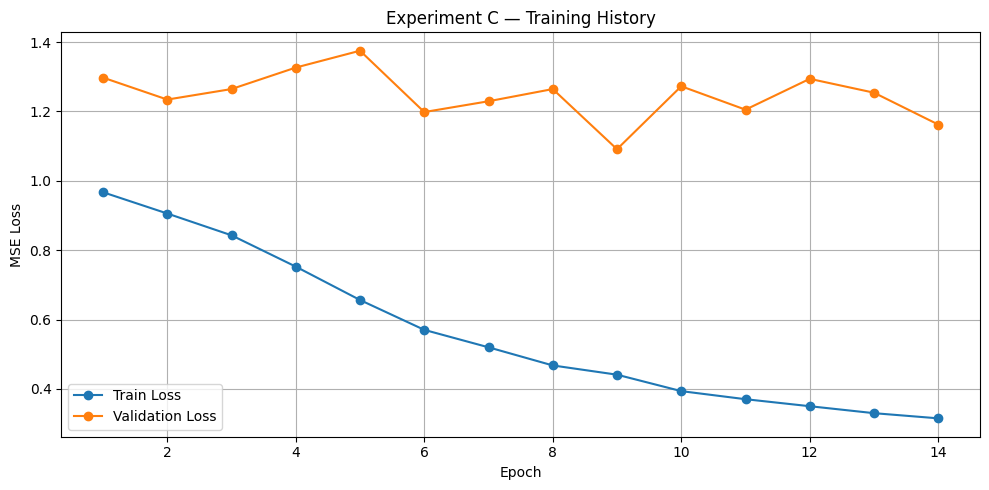

In [16]:
# ============================================================
# TRAINING CURVE
# ============================================================

epochs_done = range(
    1,
    len(history["train_loss"]) + 1
)

plt.figure(figsize=(10, 5))

plt.plot(
    epochs_done,
    history["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    epochs_done,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Experiment C — Training History")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 6. Test evaluation

The best validation checkpoint is loaded before testing.

Metrics:

- **MPJPE** — mean per-joint position error
- **PCK @ 0.05**
- **PCK @ 0.10**
- **PCK @ 0.15**
- **PCK @ 0.20**

Predictions are denormalized back to the original pose coordinate space before calculating the metrics.


In [17]:
# ============================================================
# LOAD BEST CHECKPOINT
# ============================================================

checkpoint = torch.load(
    spatial_checkpoint,
    map_location=DEVICE
)

spatial_model.load_state_dict(
    checkpoint["model_state_dict"]
)

spatial_model.eval()

print("Loaded checkpoint:")
print("Epoch:", checkpoint["epoch"])
print("Validation loss:", checkpoint["val_loss"])

Loaded checkpoint:
Epoch: 9
Validation loss: 1.0911146071222093


In [18]:
# ============================================================
# COLLECT TEST PREDICTIONS
# ============================================================

predictions_normalized = []
targets_normalized = []

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(DEVICE)

        prediction = spatial_model(x)

        predictions_normalized.append(
            prediction.cpu().numpy()
        )

        targets_normalized.append(
            y.numpy()
        )

predictions_normalized = np.concatenate(
    predictions_normalized,
    axis=0
)

targets_normalized = np.concatenate(
    targets_normalized,
    axis=0
)

print("Predictions:", predictions_normalized.shape)
print("Targets    :", targets_normalized.shape)

assert predictions_normalized.shape == (972, 17, 2)
assert targets_normalized.shape == (972, 17, 2)

Predictions: (972, 17, 2)
Targets    : (972, 17, 2)


In [19]:
# ============================================================
# DENORMALIZE
# ============================================================

predictions = (
    predictions_normalized * pose_std
) + pose_mean

targets = (
    targets_normalized * pose_std
) + pose_mean

errors = np.linalg.norm(
    predictions - targets,
    axis=2
)

print("Errors:", errors.shape)
print(
    "Mean error:",
    float(errors.mean())
)

Errors: (972, 17)
Mean error: 0.15405680239200592


In [20]:
# ============================================================
# MPJPE + PCK
# ============================================================

mpjpe = float(
    errors.mean()
)

thresholds = [
    0.05,
    0.10,
    0.15,
    0.20
]

print("========================================")
print("EXPERIMENT C — TEST EVALUATION")
print("========================================")

print("Test subjects:", TEST_SUBJECTS)
print("Test windows :", len(amp_test_dataset))
print()

print(
    f"MPJPE: {mpjpe:.6f}"
)

print()
print("PCK:")

for threshold in thresholds:

    pck = (
        errors <= threshold
    ).mean() * 100.0

    print(
        f"@ {threshold:.2f}: "
        f"{pck:.2f}%"
    )

EXPERIMENT C — TEST EVALUATION
Test subjects: [ 9 10]
Test windows : 972

MPJPE: 0.154057

PCK:
@ 0.05: 15.90%
@ 0.10: 45.21%
@ 0.15: 64.18%
@ 0.20: 75.76%


In [21]:
# ============================================================
# PER-JOINT ERROR
# ============================================================

per_joint_error = errors.mean(
    axis=0
)

print("Per-joint error:")

for j, value in enumerate(
    per_joint_error
):

    print(
        f"Joint {j + 1:02d}: "
        f"{value:.6f}"
    )

Per-joint error:
Joint 01: 0.100233
Joint 02: 0.103234
Joint 03: 0.105750
Joint 04: 0.101000
Joint 05: 0.098786
Joint 06: 0.101947
Joint 07: 0.102194
Joint 08: 0.112918
Joint 09: 0.132989
Joint 10: 0.160119
Joint 11: 0.157935
Joint 12: 0.126005
Joint 13: 0.202798
Joint 14: 0.352553
Joint 15: 0.128913
Joint 16: 0.193363
Joint 17: 0.338228


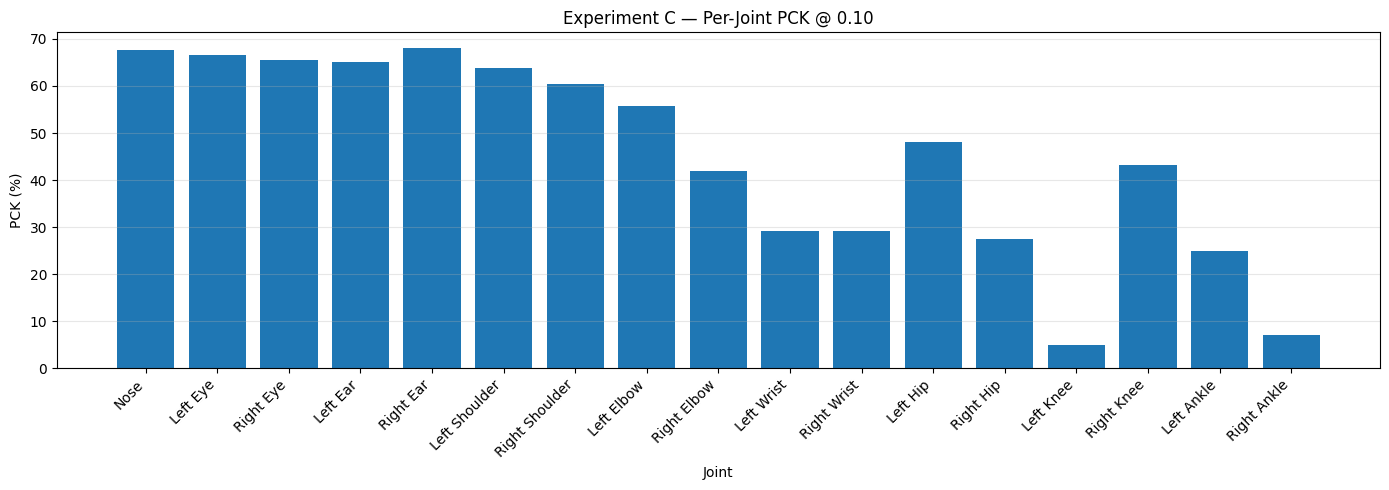

In [22]:
# ============================================================
# PER-JOINT PCK @ 0.10
# ============================================================

per_joint_pck = (
    errors <= 0.10
).mean(axis=0) * 100.0

joint_names = [
    "Nose",
    "Left Eye",
    "Right Eye",
    "Left Ear",
    "Right Ear",
    "Left Shoulder",
    "Right Shoulder",
    "Left Elbow",
    "Right Elbow",
    "Left Wrist",
    "Right Wrist",
    "Left Hip",
    "Right Hip",
    "Left Knee",
    "Right Knee",
    "Left Ankle",
    "Right Ankle"
]

plt.figure(figsize=(14, 5))

plt.bar(
    joint_names,
    per_joint_pck
)

plt.ylabel("PCK (%)")
plt.xlabel("Joint")
plt.title("Experiment C — Per-Joint PCK @ 0.10")
plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

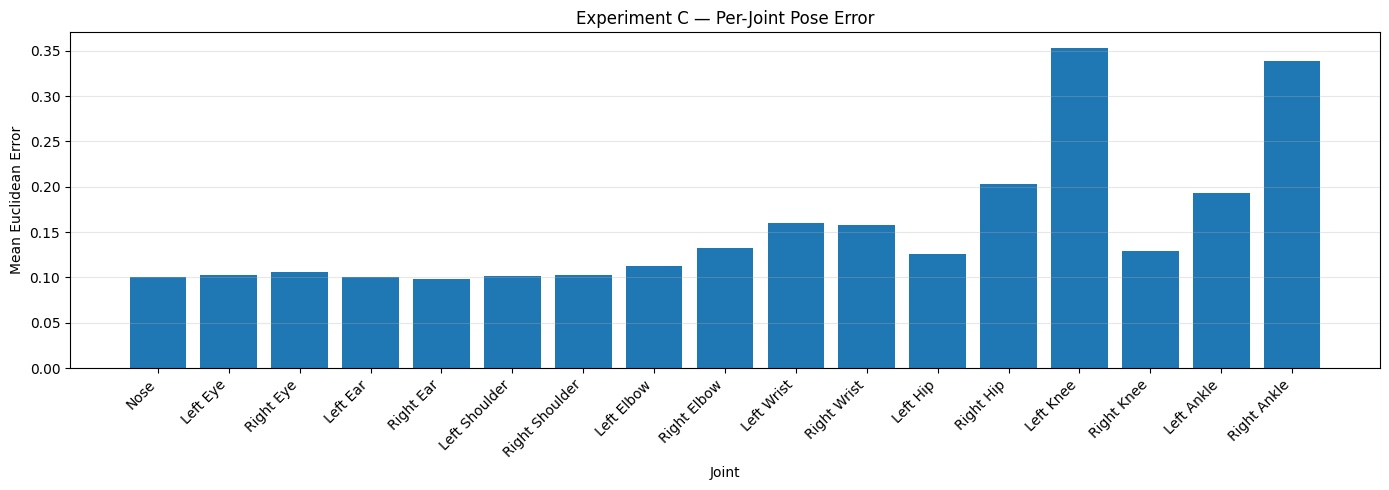

In [23]:
# ============================================================
# PER-JOINT ERROR PLOT
# ============================================================

plt.figure(figsize=(14, 5))

plt.bar(
    joint_names,
    per_joint_error
)

plt.ylabel("Mean Euclidean Error")
plt.xlabel("Joint")
plt.title("Experiment C — Per-Joint Pose Error")
plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 7. Skeleton visualization

The 17 joints follow the COCO-style ordering used by the dataset labels in this experiment.


In [24]:
# ============================================================
# SKELETON CONNECTIONS
# ============================================================

SKELETON = [
    (0, 1), (0, 2),
    (1, 3), (2, 4),

    (0, 5), (0, 6),

    (5, 7), (7, 9),
    (6, 8), (8, 10),

    (5, 11), (6, 12),
    (11, 13), (13, 15),
    (12, 14), (14, 16),

    (11, 12)
]


def plot_pose(
    target,
    prediction=None,
    title="Pose"
):

    plt.figure(figsize=(7, 7))

    # Ground truth
    plt.scatter(
        target[:, 0],
        target[:, 1],
        s=45,
        label="Ground Truth"
    )

    for a, b in SKELETON:

        plt.plot(
            [target[a, 0], target[b, 0]],
            [target[a, 1], target[b, 1]]
        )

    # Prediction
    if prediction is not None:

        plt.scatter(
            prediction[:, 0],
            prediction[:, 1],
            marker="x",
            s=55,
            label="Prediction"
        )

        for a, b in SKELETON:

            plt.plot(
                [prediction[a, 0], prediction[b, 0]],
                [prediction[a, 1], prediction[b, 1]],
                linestyle="--"
            )

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(title)

    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

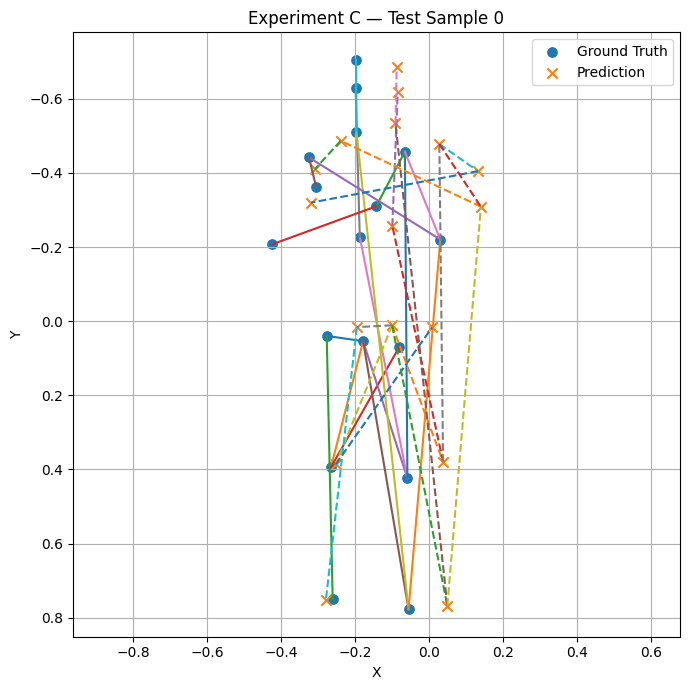

In [25]:
# ============================================================
# VISUALIZE TEST SAMPLE 0
# ============================================================

plot_pose(
    targets[0],
    predictions[0],
    title="Experiment C — Test Sample 0"
)

In [26]:
# ============================================================
# SAVE PREDICTIONS
# ============================================================

prediction_path = os.path.join(
    MODEL_DIR,
    "spatial_test_predictions.npz"
)

np.savez(
    prediction_path,
    predictions=predictions,
    targets=targets,
    errors=errors
)

print(
    "Predictions saved to:",
    prediction_path
)

Predictions saved to: C:\Users\ROHITH KANNA S\WiFiVision\models\spatial_test_predictions.npz


## 8. Final ablation comparison

Known previous results:

| Experiment | MPJPE |
|---|---:|
| Amplitude-only baseline | **0.139277** |
| Amplitude + calibrated phase | 0.146023 |
| Experiment C — richer spatial CNN | **run above** |

The lower MPJPE is better.

Do not decide the winner from training loss alone. The held-out S09–S10 MPJPE and PCK are the final comparison.


In [27]:
# ============================================================
# ABLATION SUMMARY
# ============================================================

baseline_mpjpe = 0.139277
phase_mpjpe = 0.146023

print("========================================")
print("WIFIVISION ABLATION SUMMARY")
print("========================================")

print(
    f"Amplitude baseline : "
    f"{baseline_mpjpe:.6f}"
)

print(
    f"+ Calibrated phase : "
    f"{phase_mpjpe:.6f}"
)

print(
    f"Experiment C       : "
    f"{mpjpe:.6f}"
)

print()

change_vs_baseline = (
    (mpjpe - baseline_mpjpe)
    / baseline_mpjpe
) * 100.0

print(
    f"Experiment C change vs baseline: "
    f"{change_vs_baseline:+.2f}%"
)

if mpjpe < baseline_mpjpe:
    print("Experiment C IMPROVED over the amplitude baseline.")
else:
    print("Experiment C did NOT improve over the amplitude baseline.")

WIFIVISION ABLATION SUMMARY
Amplitude baseline : 0.139277
+ Calibrated phase : 0.146023
Experiment C       : 0.154057

Experiment C change vs baseline: +10.61%
Experiment C did NOT improve over the amplitude baseline.


In [28]:
# ============================================================
# EXPERIMENT D — LIGHTWEIGHT SPATIAL ATTENTION
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F


class SpatialAttention(nn.Module):
    """
    Lightweight spatial attention.

    Input:
        (B, C, H, W)

    Output:
        (B, C, H, W)
    """

    def __init__(self, channels):
        super().__init__()

        self.attention = nn.Sequential(
            nn.Conv2d(channels, channels // 4, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // 4, 1, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        weights = self.attention(x)
        return x * weights

EXPERIMENT D — LIGHTWEIGHT SPATIAL ATTENTION
Device: cpu

Model created
------------------------------------------------------------
Parameters: 55971

Shape validation
------------------------------------------------------------
Input : (8, 30, 3, 114, 10)
Target: (8, 17, 2)
Output: (8, 17, 2)
Shape validation: PASSED

TRAINING
Epoch 01/30 | Train Loss: 1.003331 | Val Loss: 1.153619  -> Best model saved
Epoch 02/30 | Train Loss: 1.002002 | Val Loss: 1.153334  -> Best model saved
Epoch 03/30 | Train Loss: 1.001780 | Val Loss: 1.153183  -> Best model saved
Epoch 04/30 | Train Loss: 1.001733 | Val Loss: 1.153612  -> No improvement (1/5)
Epoch 05/30 | Train Loss: 1.001608 | Val Loss: 1.150838  -> Best model saved
Epoch 06/30 | Train Loss: 1.001626 | Val Loss: 1.150551  -> Best model saved
Epoch 07/30 | Train Loss: 1.001585 | Val Loss: 1.150570  -> No improvement (1/5)
Epoch 08/30 | Train Loss: 1.001575 | Val Loss: 1.151860  -> No improvement (2/5)
Epoch 09/30 | Train Loss: 1.001648 | Val 

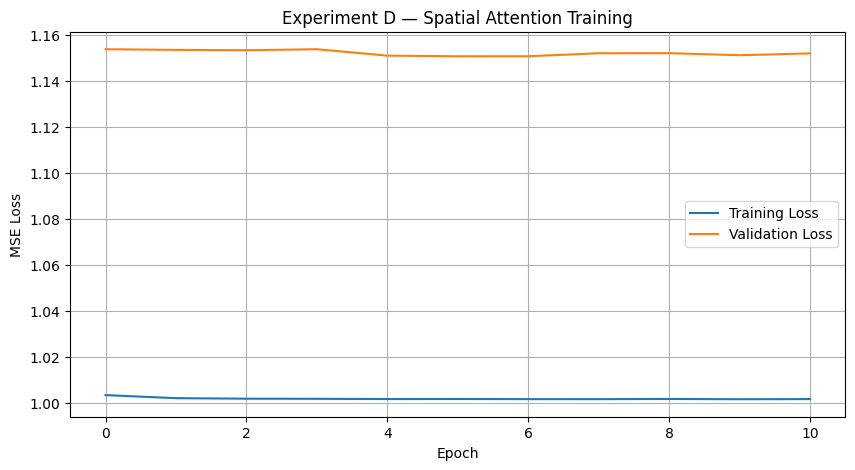


EXPERIMENT D — TEST EVALUATION
Predictions: (972, 17, 2)
Targets    : (972, 17, 2)

MPJPE: 1.023861

PCK:
@ 0.05: 0.48%
@ 0.10: 1.57%
@ 0.15: 3.58%
@ 0.20: 5.88%

Per-joint error:
Joint 01: 1.002061
Joint 02: 1.000133
Joint 03: 1.054260
Joint 04: 0.921203
Joint 05: 0.997001
Joint 06: 1.112150
Joint 07: 0.993879
Joint 08: 0.962463
Joint 09: 0.947694
Joint 10: 1.028241
Joint 11: 1.008823
Joint 12: 0.896350
Joint 13: 1.065667
Joint 14: 1.215186
Joint 15: 0.918178
Joint 16: 1.061778
Joint 17: 1.220562

Per-joint PCK @ 0.10:
Joint 01: 0.51%
Joint 02: 0.62%
Joint 03: 0.10%
Joint 04: 0.31%
Joint 05: 0.51%
Joint 06: 0.00%
Joint 07: 0.51%
Joint 08: 1.03%
Joint 09: 2.67%
Joint 10: 6.58%
Joint 11: 9.77%
Joint 12: 0.93%
Joint 13: 0.93%
Joint 14: 0.00%
Joint 15: 1.13%
Joint 16: 1.03%
Joint 17: 0.00%


FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/spatial_attention_predictions.npy'

In [29]:
# ============================================================
# EXPERIMENT D — LIGHTWEIGHT SPATIAL ATTENTION
# COMPLETE TRAINING + EVALUATION
# ============================================================

import os
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

D_CHECKPOINT = "models/spatial_attention_best.pt"

EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 1e-3

os.makedirs("models", exist_ok=True)

print("=" * 60)
print("EXPERIMENT D — LIGHTWEIGHT SPATIAL ATTENTION")
print("=" * 60)
print("Device:", DEVICE)


# ============================================================
# 1. SPATIAL ATTENTION
# ============================================================

class SpatialAttention(nn.Module):

    def __init__(self, channels):
        super().__init__()

        hidden = max(channels // 4, 1)

        self.attention = nn.Sequential(
            nn.Conv2d(
                channels,
                hidden,
                kernel_size=1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                hidden,
                1,
                kernel_size=1
            ),

            nn.Sigmoid()
        )

    def forward(self, x):

        weights = self.attention(x)

        return x * weights


# ============================================================
# 2. EXPERIMENT D MODEL
# ============================================================

class SpatialAttentionCSI2Pose(nn.Module):

    def __init__(self):

        super().__init__()

        # ----------------------------------------------------
        # SAME FRAME CNN AS BASELINE
        # ----------------------------------------------------

        self.frame_cnn = nn.Sequential(

            nn.Conv2d(
                3,
                16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        # ----------------------------------------------------
        # NEW COMPONENT
        # ----------------------------------------------------

        self.spatial_attention = SpatialAttention(64)

        # ----------------------------------------------------
        # SAME TEMPORAL / POSE HEAD
        # ----------------------------------------------------

        self.temporal = nn.GRU(
            input_size=64,
            hidden_size=64,
            batch_first=True
        )

        self.pose_head = nn.Sequential(

            nn.Linear(64, 64),
            nn.ReLU(inplace=True),

            nn.Linear(
                64,
                17 * 2
            )
        )

    def forward(self, x):

        # x:
        # (B, T, 3, 114, 10)

        B, T, C, H, W = x.shape

        # ----------------------------------------------------
        # PROCESS EACH FRAME
        # ----------------------------------------------------

        x = x.reshape(
            B * T,
            C,
            H,
            W
        )

        # CNN
        x = self.frame_cnn(x)

        # ----------------------------------------------------
        # SPATIAL ATTENTION
        # ----------------------------------------------------

        x = self.spatial_attention(x)

        # ----------------------------------------------------
        # GLOBAL FEATURE
        # ----------------------------------------------------

        x = x.flatten(1)

        # (B*T, 64)

        x = x.reshape(
            B,
            T,
            64
        )

        # ----------------------------------------------------
        # TEMPORAL MODEL
        # ----------------------------------------------------

        x, _ = self.temporal(x)

        # Use final temporal representation
        x = x[:, -1, :]

        # ----------------------------------------------------
        # POSE
        # ----------------------------------------------------

        x = self.pose_head(x)

        x = x.reshape(
            B,
            17,
            2
        )

        return x


# ============================================================
# 3. CREATE MODEL
# ============================================================

spatial_model = SpatialAttentionCSI2Pose().to(DEVICE)

parameter_count = sum(
    p.numel()
    for p in spatial_model.parameters()
    if p.requires_grad
)

print()
print("Model created")
print("-" * 60)
print("Parameters:", parameter_count)


# ============================================================
# 4. SHAPE VALIDATION
# ============================================================

sample_x, sample_y = next(iter(train_loader))

print()
print("Shape validation")
print("-" * 60)

print("Input :", tuple(sample_x.shape))
print("Target:", tuple(sample_y.shape))

sample_x = sample_x.to(DEVICE)

with torch.no_grad():

    sample_output = spatial_model(sample_x)

print("Output:", tuple(sample_output.shape))

assert sample_output.shape[-2:] == (17, 2)

print("Shape validation: PASSED")


# ============================================================
# 5. LOSS / OPTIMIZER
# ============================================================

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    spatial_model.parameters(),
    lr=LEARNING_RATE
)


# ============================================================
# 6. TRAINING
# ============================================================

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

best_state = None

print()
print("=" * 60)
print("TRAINING")
print("=" * 60)

for epoch in range(EPOCHS):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    spatial_model.train()

    running_train_loss = 0.0
    train_count = 0

    for x, y in train_loader:

        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()

        prediction = spatial_model(x)

        loss = criterion(
            prediction,
            y
        )

        loss.backward()

        optimizer.step()

        batch_size = x.size(0)

        running_train_loss += (
            loss.item() * batch_size
        )

        train_count += batch_size

    train_loss = (
        running_train_loss /
        train_count
    )

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    spatial_model.eval()

    running_val_loss = 0.0
    val_count = 0

    with torch.no_grad():

        for x, y in val_loader:

            x = x.to(DEVICE)
            y = y.to(DEVICE)

            prediction = spatial_model(x)

            loss = criterion(
                prediction,
                y
            )

            batch_size = x.size(0)

            running_val_loss += (
                loss.item() * batch_size
            )

            val_count += batch_size

    val_loss = (
        running_val_loss /
        val_count
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}",
        end=""
    )

    # --------------------------------------------------------
    # CHECKPOINT
    # --------------------------------------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        best_state = copy.deepcopy(
            spatial_model.state_dict()
        )

        torch.save(
            {
                "model_state_dict":
                    spatial_model.state_dict(),

                "best_val_loss":
                    best_val_loss,

                "epoch":
                    epoch + 1,

                "parameters":
                    parameter_count
            },
            D_CHECKPOINT
        )

        print("  -> Best model saved")

    else:

        patience_counter += 1

        print(
            f"  -> No improvement "
            f"({patience_counter}/{PATIENCE})"
        )

        if patience_counter >= PATIENCE:

            print()
            print("Early stopping.")
            break


# ============================================================
# 7. RESTORE BEST MODEL
# ============================================================

if best_state is not None:

    spatial_model.load_state_dict(
        best_state
    )

print()
print("=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

print(
    f"Best validation loss: "
    f"{best_val_loss:.6f}"
)

print(
    f"Checkpoint: "
    f"{D_CHECKPOINT}"
)


# ============================================================
# 8. TRAINING CURVE
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title(
    "Experiment D — Spatial Attention Training"
)

plt.grid(True)
plt.legend()

plt.show()


# ============================================================
# 9. TEST EVALUATION
# ============================================================

spatial_model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(DEVICE)

        prediction = spatial_model(x)

        all_predictions.append(
            prediction.cpu().numpy()
        )

        all_targets.append(
            y.numpy()
        )

predictions = np.concatenate(
    all_predictions,
    axis=0
)

targets = np.concatenate(
    all_targets,
    axis=0
)

print()
print("=" * 60)
print("EXPERIMENT D — TEST EVALUATION")
print("=" * 60)

print("Predictions:", predictions.shape)
print("Targets    :", targets.shape)


# ============================================================
# 10. MPJPE
# ============================================================

errors = np.linalg.norm(
    predictions - targets,
    axis=2
)

mpjpe = errors.mean()

print()
print(f"MPJPE: {mpjpe:.6f}")


# ============================================================
# 11. PCK
# ============================================================

thresholds = [
    0.05,
    0.10,
    0.15,
    0.20
]

print()
print("PCK:")

for threshold in thresholds:

    pck = (
        errors < threshold
    ).mean() * 100

    print(
        f"@ {threshold:.2f}: "
        f"{pck:.2f}%"
    )


# ============================================================
# 12. PER-JOINT ERROR
# ============================================================

joint_errors = errors.mean(axis=0)

print()
print("Per-joint error:")

for i, error in enumerate(
    joint_errors,
    start=1
):

    print(
        f"Joint {i:02d}: "
        f"{error:.6f}"
    )


# ============================================================
# 13. PER-JOINT PCK @ 0.10
# ============================================================

joint_pck = (
    errors < 0.10
).mean(axis=0) * 100

print()
print("Per-joint PCK @ 0.10:")

for i, pck in enumerate(
    joint_pck,
    start=1
):

    print(
        f"Joint {i:02d}: "
        f"{pck:.2f}%"
    )


# ============================================================
# 14. SAVE PREDICTIONS
# ============================================================

np.save(
    "data/processed/"
    "spatial_attention_predictions.npy",
    predictions
)

np.save(
    "data/processed/"
    "spatial_attention_targets.npy",
    targets
)

np.save(
    "data/processed/"
    "spatial_attention_errors.npy",
    errors
)

print()
print("Predictions saved.")


# ============================================================
# 15. BASELINE COMPARISON
# ============================================================

baseline_mpjpe = 0.139277
phase_mpjpe = 0.146023
experiment_c_mpjpe = 0.154057

change_vs_baseline = (
    (mpjpe - baseline_mpjpe)
    / baseline_mpjpe
) * 100

print()
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print(
    f"Amplitude baseline : "
    f"{baseline_mpjpe:.6f}"
)

print(
    f"Calibrated phase   : "
    f"{phase_mpjpe:.6f}"
)

print(
    f"Experiment C       : "
    f"{experiment_c_mpjpe:.6f}"
)

print(
    f"Experiment D       : "
    f"{mpjpe:.6f}"
)

print()
print(
    f"Experiment D change "
    f"vs baseline: "
    f"{change_vs_baseline:+.2f}%"
)

if mpjpe < baseline_mpjpe:

    print()
    print(
        "RESULT: Experiment D "
        "IMPROVED over the baseline."
    )

else:

    print()
    print(
        "RESULT: Experiment D "
        "DID NOT improve over the baseline."
    )

In [31]:
# ============================================================
# RECOVER THE EXACT BASELINE MODEL
# ============================================================

baseline_file = os.path.join(
    ROOT,
    "baseline_model.py"
)

print("Baseline file:")
print(baseline_file)

if not os.path.exists(baseline_file):
    raise FileNotFoundError(
        f"Could not find:\n{baseline_file}"
    )

with open(
    baseline_file,
    "r",
    encoding="utf-8"
) as f:
    baseline_code = f.read()

print()
print("=" * 70)
print("BASELINE MODEL CODE")
print("=" * 70)
print(baseline_code)

Baseline file:
C:\Users\ROHITH KANNA S\WiFiVision\baseline_model.py

BASELINE MODEL CODE
import torch
import torch.nn as nn


class CSIFrameCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=3,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(16),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            ),

            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            ),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )


    def forward(self, x):

        # x:
        # (batch, 3, 114, 10)

        x = self.

Device: cpu

MODEL CHECK
Experiment D parameters: 36979
Baseline parameters    : 36706
Additional parameters  : 273

Parameter check: PASSED

SHAPE CHECK
Input : (8, 30, 3, 114, 10)
Output: (8, 17, 2)

Shape check: PASSED

EXPERIMENT D — TRAINING
Epoch 01/30 | Train Loss: 0.992926 | Val Loss: 1.169444  -> Best model saved
Epoch 02/30 | Train Loss: 0.974731 | Val Loss: 1.129972  -> Best model saved
Epoch 03/30 | Train Loss: 0.956779 | Val Loss: 1.156435  -> No improvement (1/5)
Epoch 04/30 | Train Loss: 0.936510 | Val Loss: 1.320860  -> No improvement (2/5)
Epoch 05/30 | Train Loss: 0.925321 | Val Loss: 1.126975  -> Best model saved
Epoch 06/30 | Train Loss: 0.899486 | Val Loss: 1.181286  -> No improvement (1/5)
Epoch 07/30 | Train Loss: 0.881233 | Val Loss: 1.218256  -> No improvement (2/5)
Epoch 08/30 | Train Loss: 0.863851 | Val Loss: 1.169566  -> No improvement (3/5)
Epoch 09/30 | Train Loss: 0.862116 | Val Loss: 1.276359  -> No improvement (4/5)
Epoch 10/30 | Train Loss: 0.849029 |

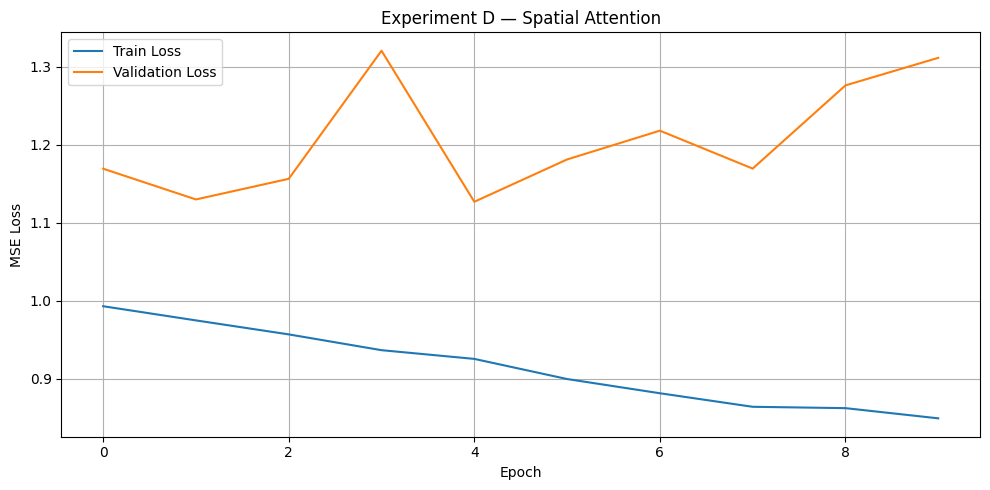


TEST OUTPUT
Predictions: (972, 17, 2)
Targets    : (972, 17, 2)

Predictions denormalized.

EXPERIMENT D — TEST EVALUATION
MPJPE: 0.142358

PCK:
@ 0.05: 21.56%
@ 0.10: 53.03%
@ 0.15: 69.05%
@ 0.20: 78.07%

Per-joint error:
Joint 01: 0.093999
Joint 02: 0.093715
Joint 03: 0.085145
Joint 04: 0.073373
Joint 05: 0.094314
Joint 06: 0.107738
Joint 07: 0.107943
Joint 08: 0.102505
Joint 09: 0.117564
Joint 10: 0.143943
Joint 11: 0.142393
Joint 12: 0.109907
Joint 13: 0.186267
Joint 14: 0.340326
Joint 15: 0.114813
Joint 16: 0.177388
Joint 17: 0.328753

Results saved to:
C:\Users\ROHITH KANNA S\WiFiVision\data\processed\experiment_D

FINAL ABLATION COMPARISON
Amplitude baseline : 0.139277
Calibrated phase   : 0.146023
Experiment C       : 0.154057
Experiment D       : 0.142358

D vs baseline: +2.21%

RESULT: Spatial attention did NOT improve the baseline.


In [32]:
# ============================================================
# EXPERIMENT D — EXACT BASELINE + LIGHTWEIGHT SPATIAL ATTENTION
# ============================================================

import os
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader


# ============================================================
# CONFIGURATION
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

EPOCHS = 30
BATCH_SIZE = 8
LEARNING_RATE = 1e-3
PATIENCE = 5

D_CHECKPOINT = os.path.join(
    ROOT,
    "models",
    "spatial_attention_best.pt"
)

os.makedirs(
    os.path.dirname(D_CHECKPOINT),
    exist_ok=True
)

print("Device:", DEVICE)


# ============================================================
# 1. EXACT BASELINE FRAME CNN + SPATIAL ATTENTION
# ============================================================

class SpatialAttention(nn.Module):

    def __init__(self, channels=32):

        super().__init__()

        hidden = channels // 4

        self.attention = nn.Sequential(

            nn.Conv2d(
                channels,
                hidden,
                kernel_size=1
            ),

            nn.ReLU(),

            nn.Conv2d(
                hidden,
                1,
                kernel_size=1
            ),

            nn.Sigmoid()
        )

    def forward(self, x):

        weights = self.attention(x)

        return x * weights


class CSIFrameCNNWithAttention(nn.Module):

    def __init__(self):

        super().__init__()

        # ----------------------------------------------------
        # EXACT BASELINE CNN
        # ----------------------------------------------------

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=3,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(16),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            ),

            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            )
        )

        # ----------------------------------------------------
        # ONLY NEW COMPONENT
        # ----------------------------------------------------

        self.spatial_attention = SpatialAttention(
            channels=32
        )

        # ----------------------------------------------------
        # EXACT BASELINE GLOBAL POOLING
        # ----------------------------------------------------

        self.pool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )

    def forward(self, x):

        # (B, 3, 114, 10)
        x = self.features(x)

        # (B, 32, 28, 2)
        #
        # Attention is applied HERE,
        # before spatial information is destroyed.

        x = self.spatial_attention(x)

        # (B, 32, 28, 2)
        x = self.pool(x)

        # (B, 32, 1, 1)
        x = x.flatten(1)

        # (B, 32)
        return x


# ============================================================
# 2. EXACT BASELINE TEMPORAL + POSE HEAD
# ============================================================

class CSI2PoseAttention(nn.Module):

    def __init__(self):

        super().__init__()

        self.frame_cnn = (
            CSIFrameCNNWithAttention()
        )

        # EXACT BASELINE GRU
        self.gru = nn.GRU(
            input_size=32,
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )

        # EXACT BASELINE HEAD
        self.head = nn.Sequential(

            nn.Linear(
                64,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                34
            )
        )

    def forward(self, x):

        # ----------------------------------------------------
        # Input:
        # (B, 30, 3, 114, 10)
        # ----------------------------------------------------

        batch_size = x.shape[0]

        sequence_length = x.shape[1]

        # ----------------------------------------------------
        # Process every frame
        # ----------------------------------------------------

        x = x.reshape(
            batch_size * sequence_length,
            3,
            114,
            10
        )

        x = self.frame_cnn(x)

        # (B*30, 32)

        # ----------------------------------------------------
        # Restore temporal dimension
        # ----------------------------------------------------

        x = x.reshape(
            batch_size,
            sequence_length,
            32
        )

        # ----------------------------------------------------
        # EXACT BASELINE GRU
        # ----------------------------------------------------

        x, _ = self.gru(x)

        # (B, 30, 64)

        # Final temporal representation
        x = x[:, -1, :]

        # (B, 64)

        # ----------------------------------------------------
        # EXACT BASELINE POSE HEAD
        # ----------------------------------------------------

        x = self.head(x)

        # (B, 34)

        x = x.reshape(
            batch_size,
            17,
            2
        )

        return x


# ============================================================
# 3. CREATE MODEL
# ============================================================

model_D = CSI2PoseAttention().to(DEVICE)

parameters_D = sum(
    p.numel()
    for p in model_D.parameters()
    if p.requires_grad
)

print()
print("=" * 60)
print("MODEL CHECK")
print("=" * 60)

print(
    "Experiment D parameters:",
    parameters_D
)

print(
    "Baseline parameters    :",
    36706
)

print(
    "Additional parameters  :",
    parameters_D - 36706
)


# ============================================================
# 4. PARAMETER SANITY CHECK
# ============================================================

assert parameters_D == 36979, (
    f"Unexpected parameter count: {parameters_D}"
)

print()
print("Parameter check: PASSED")


# ============================================================
# 5. INPUT / OUTPUT SHAPE CHECK
# ============================================================

x_test, y_test = next(
    iter(train_loader)
)

x_test = x_test.to(DEVICE)

with torch.no_grad():

    output_test = model_D(
        x_test
    )

print()
print("=" * 60)
print("SHAPE CHECK")
print("=" * 60)

print(
    "Input :",
    tuple(x_test.shape)
)

print(
    "Output:",
    tuple(output_test.shape)
)

assert tuple(output_test.shape) == (
    x_test.shape[0],
    17,
    2
)

print()
print("Shape check: PASSED")


# ============================================================
# 6. TRAINING
# ============================================================

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model_D.parameters(),
    lr=LEARNING_RATE
)

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

best_state = None

print()
print("=" * 60)
print("EXPERIMENT D — TRAINING")
print("=" * 60)

for epoch in range(
    1,
    EPOCHS + 1
):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model_D.train()

    train_loss_sum = 0.0
    train_count = 0

    for x, y in train_loader:

        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()

        prediction = model_D(x)

        loss = criterion(
            prediction,
            y
        )

        loss.backward()

        optimizer.step()

        batch_size = x.size(0)

        train_loss_sum += (
            loss.item() * batch_size
        )

        train_count += batch_size

    train_loss = (
        train_loss_sum /
        train_count
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model_D.eval()

    val_loss_sum = 0.0
    val_count = 0

    with torch.no_grad():

        for x, y in val_loader:

            x = x.to(DEVICE)
            y = y.to(DEVICE)

            prediction = model_D(x)

            loss = criterion(
                prediction,
                y
            )

            batch_size = x.size(0)

            val_loss_sum += (
                loss.item() * batch_size
            )

            val_count += batch_size

    val_loss = (
        val_loss_sum /
        val_count
    )

    train_losses.append(
        train_loss
    )

    val_losses.append(
        val_loss
    )


    # --------------------------------------------------------
    # REPORT
    # --------------------------------------------------------

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}",
        end=""
    )


    # --------------------------------------------------------
    # BEST MODEL
    # --------------------------------------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        patience_counter = 0

        best_state = copy.deepcopy(
            model_D.state_dict()
        )

        torch.save(
            {
                "model_state_dict":
                    model_D.state_dict(),

                "val_loss":
                    best_val_loss,

                "epoch":
                    epoch,

                "parameters":
                    parameters_D
            },
            D_CHECKPOINT
        )

        print(
            "  -> Best model saved"
        )

    else:

        patience_counter += 1

        print(
            f"  -> No improvement "
            f"({patience_counter}/{PATIENCE})"
        )


    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if patience_counter >= PATIENCE:

        print()
        print("Early stopping.")
        break


# ============================================================
# 7. RESTORE BEST MODEL
# ============================================================

model_D.load_state_dict(
    best_state
)

model_D.eval()

print()
print("=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

print(
    "Best validation loss:",
    best_val_loss
)

print(
    "Checkpoint:",
    D_CHECKPOINT
)


# ============================================================
# 8. TRAINING CURVE
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title(
    "Experiment D — Spatial Attention"
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 9. TEST PREDICTIONS
# ============================================================

all_predictions = []
all_targets = []

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(DEVICE)

        prediction = model_D(x)

        all_predictions.append(
            prediction.cpu().numpy()
        )

        all_targets.append(
            y.numpy()
        )


predictions_normalized = np.concatenate(
    all_predictions,
    axis=0
)

targets_normalized = np.concatenate(
    all_targets,
    axis=0
)

print()
print("=" * 60)
print("TEST OUTPUT")
print("=" * 60)

print(
    "Predictions:",
    predictions_normalized.shape
)

print(
    "Targets    :",
    targets_normalized.shape
)


# ============================================================
# 10. CRITICAL — DENORMALIZE
# ============================================================

predictions = (
    predictions_normalized
    * pose_std
) + pose_mean

targets = (
    targets_normalized
    * pose_std
) + pose_mean

print()
print(
    "Predictions denormalized."
)


# ============================================================
# 11. MPJPE
# ============================================================

errors = np.linalg.norm(
    predictions - targets,
    axis=2
)

mpjpe_D = float(
    errors.mean()
)

print()
print("=" * 60)
print("EXPERIMENT D — TEST EVALUATION")
print("=" * 60)

print(
    f"MPJPE: {mpjpe_D:.6f}"
)


# ============================================================
# 12. PCK
# ============================================================

thresholds = [
    0.05,
    0.10,
    0.15,
    0.20
]

print()
print("PCK:")

for threshold in thresholds:

    pck = (
        errors <= threshold
    ).mean() * 100

    print(
        f"@ {threshold:.2f}: "
        f"{pck:.2f}%"
    )


# ============================================================
# 13. PER-JOINT ERROR
# ============================================================

joint_errors = errors.mean(
    axis=0
)

print()
print("Per-joint error:")

for i, error in enumerate(
    joint_errors,
    start=1
):

    print(
        f"Joint {i:02d}: "
        f"{error:.6f}"
    )


# ============================================================
# 14. SAVE RESULTS
# ============================================================

RESULT_DIR = os.path.join(
    ROOT,
    "data",
    "processed",
    "experiment_D"
)

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

np.save(
    os.path.join(
        RESULT_DIR,
        "predictions.npy"
    ),
    predictions
)

np.save(
    os.path.join(
        RESULT_DIR,
        "targets.npy"
    ),
    targets
)

np.save(
    os.path.join(
        RESULT_DIR,
        "errors.npy"
    ),
    errors
)

print()
print(
    "Results saved to:"
)

print(
    RESULT_DIR
)


# ============================================================
# 15. FINAL COMPARISON
# ============================================================

baseline_mpjpe = 0.139277
phase_mpjpe = 0.146023
experiment_C_mpjpe = 0.154057

change_D = (
    (
        mpjpe_D -
        baseline_mpjpe
    )
    /
    baseline_mpjpe
) * 100

print()
print("=" * 60)
print("FINAL ABLATION COMPARISON")
print("=" * 60)

print(
    f"Amplitude baseline : "
    f"{baseline_mpjpe:.6f}"
)

print(
    f"Calibrated phase   : "
    f"{phase_mpjpe:.6f}"
)

print(
    f"Experiment C       : "
    f"{experiment_C_mpjpe:.6f}"
)

print(
    f"Experiment D       : "
    f"{mpjpe_D:.6f}"
)

print()
print(
    f"D vs baseline: "
    f"{change_D:+.2f}%"
)

if mpjpe_D < baseline_mpjpe:

    print()
    print(
        "RESULT: Spatial attention "
        "improved the baseline."
    )

else:

    print()
    print(
        "RESULT: Spatial attention "
        "did NOT improve the baseline."
    )

Device: cpu

MODEL CHECK
Experiment E parameters: 22338
Baseline parameters    : 36706

Input : (8, 30, 3, 114, 10)
Output: (8, 17, 2)

Shape check: PASSED

EXPERIMENT E — TEMPORAL TRANSFORMER TRAINING
Epoch 01/30 | Train Loss: 0.994078 | Val Loss: 1.177577  -> Best model saved
Epoch 02/30 | Train Loss: 0.967343 | Val Loss: 1.119159  -> Best model saved
Epoch 03/30 | Train Loss: 0.949921 | Val Loss: 1.126842  -> No improvement (1/5)
Epoch 04/30 | Train Loss: 0.936130 | Val Loss: 1.120236  -> No improvement (2/5)
Epoch 05/30 | Train Loss: 0.924621 | Val Loss: 1.157829  -> No improvement (3/5)
Epoch 06/30 | Train Loss: 0.911296 | Val Loss: 1.106137  -> Best model saved
Epoch 07/30 | Train Loss: 0.906915 | Val Loss: 1.125391  -> No improvement (1/5)
Epoch 08/30 | Train Loss: 0.885838 | Val Loss: 1.138067  -> No improvement (2/5)
Epoch 09/30 | Train Loss: 0.899981 | Val Loss: 1.143412  -> No improvement (3/5)
Epoch 10/30 | Train Loss: 0.875766 | Val Loss: 1.194281  -> No improvement (4/5)


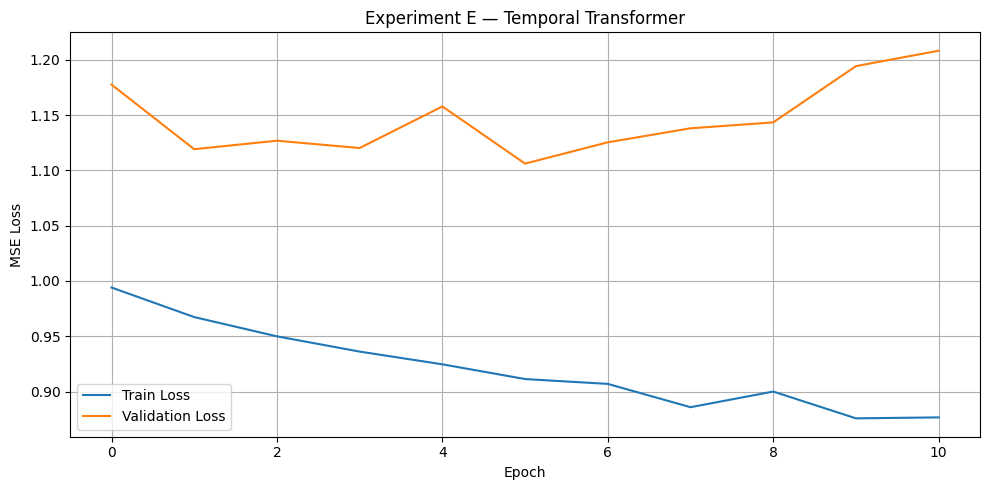


TEST OUTPUT
Predictions: (972, 17, 2)
Targets    : (972, 17, 2)

Predictions denormalized.

EXPERIMENT E — TEST EVALUATION
MPJPE: 0.147049

PCK:
@ 0.05: 17.73%
@ 0.10: 51.19%
@ 0.15: 68.10%
@ 0.20: 76.68%

Per-joint error:
Joint 01: 0.100298
Joint 02: 0.101063
Joint 03: 0.093293
Joint 04: 0.085528
Joint 05: 0.100872
Joint 06: 0.097897
Joint 07: 0.092252
Joint 08: 0.110149
Joint 09: 0.125933
Joint 10: 0.145001
Joint 11: 0.146188
Joint 12: 0.118998
Joint 13: 0.193076
Joint 14: 0.340130
Joint 15: 0.122655
Joint 16: 0.191318
Joint 17: 0.335182

Results saved to:
C:\Users\ROHITH KANNA S\WiFiVision\data\processed\experiment_E

FINAL ABLATION COMPARISON
Amplitude baseline : 0.139277
Calibrated phase   : 0.146023
Experiment C       : 0.154057
Experiment D       : 0.142358
Experiment E       : 0.147049

E vs baseline: +5.58%

RESULT: Temporal Transformer DID NOT improve the baseline.


In [33]:
# ============================================================
# EXPERIMENT E — TEMPORAL TRANSFORMER
# EXACT BASELINE CNN + TRANSFORMER
# ============================================================

import os
import copy
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# ============================================================
# CONFIGURATION
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

EPOCHS = 30
LEARNING_RATE = 1e-3
PATIENCE = 5

E_CHECKPOINT = os.path.join(
    ROOT,
    "models",
    "temporal_transformer_best.pt"
)

os.makedirs(
    os.path.dirname(E_CHECKPOINT),
    exist_ok=True
)

print("Device:", DEVICE)


# ============================================================
# 1. EXACT BASELINE FRAME CNN
# ============================================================

class CSIFrameCNN_E(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=3,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(16),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            ),

            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            ),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = x.flatten(1)

        return x


# ============================================================
# 2. SINUSOIDAL POSITIONAL ENCODING
# ============================================================

class PositionalEncoding(nn.Module):

    def __init__(
        self,
        d_model,
        max_len=30
    ):

        super().__init__()

        position = torch.arange(
            max_len,
            dtype=torch.float32
        ).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(
                0,
                d_model,
                2,
                dtype=torch.float32
            )
            *
            (
                -math.log(10000.0)
                / d_model
            )
        )

        pe = torch.zeros(
            max_len,
            d_model
        )

        pe[:, 0::2] = torch.sin(
            position * div_term
        )

        pe[:, 1::2] = torch.cos(
            position * div_term
        )

        pe = pe.unsqueeze(0)

        # Shape:
        # (1, max_len, d_model)

        self.register_buffer(
            "pe",
            pe
        )

    def forward(self, x):

        # x:
        # (B, T, d_model)

        sequence_length = x.size(1)

        return (
            x +
            self.pe[:, :sequence_length, :]
        )


# ============================================================
# 3. EXACT BASELINE POSE HEAD
# ============================================================

class TemporalTransformerCSI2Pose(nn.Module):

    def __init__(self):

        super().__init__()

        # ----------------------------------------------------
        # EXACT BASELINE CNN
        # ----------------------------------------------------

        self.frame_cnn = CSIFrameCNN_E()

        # ----------------------------------------------------
        # POSITIONAL ENCODING
        # ----------------------------------------------------

        self.position = PositionalEncoding(
            d_model=32,
            max_len=30
        )

        # ----------------------------------------------------
        # SMALL TEMPORAL TRANSFORMER
        #
        # 32-dimensional representation
        # 4 attention heads
        # 1 encoder layer
        # ----------------------------------------------------

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=32,
            nhead=4,
            dim_feedforward=64,
            dropout=0.1,
            activation="gelu",
            batch_first=True,
            norm_first=False
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=1
        )

        # ----------------------------------------------------
        # EXACT BASELINE POSE HEAD
        # ----------------------------------------------------

        self.head = nn.Sequential(

            nn.Linear(
                32,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                34
            )
        )

    def forward(self, x):

        # ----------------------------------------------------
        # INPUT
        #
        # (B, 30, 3, 114, 10)
        # ----------------------------------------------------

        batch_size = x.shape[0]

        sequence_length = x.shape[1]

        # ----------------------------------------------------
        # PROCESS EACH FRAME
        # ----------------------------------------------------

        x = x.reshape(
            batch_size * sequence_length,
            3,
            114,
            10
        )

        # (B*30, 32)

        x = self.frame_cnn(x)

        # ----------------------------------------------------
        # RESTORE TEMPORAL DIMENSION
        # ----------------------------------------------------

        x = x.reshape(
            batch_size,
            sequence_length,
            32
        )

        # (B, 30, 32)

        # ----------------------------------------------------
        # POSITIONAL INFORMATION
        # ----------------------------------------------------

        x = self.position(x)

        # ----------------------------------------------------
        # TEMPORAL TRANSFORMER
        # ----------------------------------------------------

        x = self.transformer(x)

        # (B, 30, 32)

        # ----------------------------------------------------
        # FINAL FRAME REPRESENTATION
        # ----------------------------------------------------

        x = x[:, -1, :]

        # (B, 32)

        # ----------------------------------------------------
        # POSE PREDICTION
        # ----------------------------------------------------

        x = self.head(x)

        # (B, 34)

        x = x.reshape(
            batch_size,
            17,
            2
        )

        return x


# ============================================================
# 4. CREATE MODEL
# ============================================================

model_E = TemporalTransformerCSI2Pose().to(
    DEVICE
)

parameters_E = sum(
    p.numel()
    for p in model_E.parameters()
    if p.requires_grad
)

print()
print("=" * 60)
print("MODEL CHECK")
print("=" * 60)

print(
    "Experiment E parameters:",
    parameters_E
)

print(
    "Baseline parameters    :",
    36706
)


# ============================================================
# 5. INPUT / OUTPUT CHECK
# ============================================================

x_test, y_test = next(
    iter(train_loader)
)

x_test = x_test.to(DEVICE)

with torch.no_grad():

    output_test = model_E(
        x_test
    )

print()
print("Input :", tuple(x_test.shape))
print("Output:", tuple(output_test.shape))

assert tuple(output_test.shape) == (
    x_test.shape[0],
    17,
    2
)

print()
print("Shape check: PASSED")


# ============================================================
# 6. TRAINING
# ============================================================

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model_E.parameters(),
    lr=LEARNING_RATE
)

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

best_state = None

print()
print("=" * 60)
print("EXPERIMENT E — TEMPORAL TRANSFORMER TRAINING")
print("=" * 60)

for epoch in range(
    1,
    EPOCHS + 1
):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model_E.train()

    train_loss_sum = 0.0
    train_count = 0

    for x, y in train_loader:

        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()

        prediction = model_E(x)

        loss = criterion(
            prediction,
            y
        )

        loss.backward()

        optimizer.step()

        batch_size = x.size(0)

        train_loss_sum += (
            loss.item() * batch_size
        )

        train_count += batch_size

    train_loss = (
        train_loss_sum /
        train_count
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model_E.eval()

    val_loss_sum = 0.0
    val_count = 0

    with torch.no_grad():

        for x, y in val_loader:

            x = x.to(DEVICE)
            y = y.to(DEVICE)

            prediction = model_E(x)

            loss = criterion(
                prediction,
                y
            )

            batch_size = x.size(0)

            val_loss_sum += (
                loss.item() * batch_size
            )

            val_count += batch_size

    val_loss = (
        val_loss_sum /
        val_count
    )

    train_losses.append(
        train_loss
    )

    val_losses.append(
        val_loss
    )


    # --------------------------------------------------------
    # REPORT
    # --------------------------------------------------------

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}",
        end=""
    )


    # --------------------------------------------------------
    # CHECKPOINT
    # --------------------------------------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        patience_counter = 0

        best_state = copy.deepcopy(
            model_E.state_dict()
        )

        torch.save(
            {
                "model_state_dict":
                    model_E.state_dict(),

                "val_loss":
                    best_val_loss,

                "epoch":
                    epoch,

                "parameters":
                    parameters_E
            },
            E_CHECKPOINT
        )

        print(
            "  -> Best model saved"
        )

    else:

        patience_counter += 1

        print(
            f"  -> No improvement "
            f"({patience_counter}/{PATIENCE})"
        )


    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if patience_counter >= PATIENCE:

        print()
        print("Early stopping.")
        break


# ============================================================
# 7. RESTORE BEST MODEL
# ============================================================

model_E.load_state_dict(
    best_state
)

model_E.eval()

print()
print("=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

print(
    "Best validation loss:",
    best_val_loss
)

print(
    "Checkpoint:",
    E_CHECKPOINT
)


# ============================================================
# 8. TRAINING CURVE
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title(
    "Experiment E — Temporal Transformer"
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 9. TEST PREDICTIONS
# ============================================================

all_predictions = []
all_targets = []

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(DEVICE)

        prediction = model_E(x)

        all_predictions.append(
            prediction.cpu().numpy()
        )

        all_targets.append(
            y.numpy()
        )


predictions_normalized = np.concatenate(
    all_predictions,
    axis=0
)

targets_normalized = np.concatenate(
    all_targets,
    axis=0
)

print()
print("=" * 60)
print("TEST OUTPUT")
print("=" * 60)

print(
    "Predictions:",
    predictions_normalized.shape
)

print(
    "Targets    :",
    targets_normalized.shape
)


# ============================================================
# 10. DENORMALIZE
# ============================================================

predictions = (
    predictions_normalized
    * pose_std
) + pose_mean

targets = (
    targets_normalized
    * pose_std
) + pose_mean

print()
print("Predictions denormalized.")


# ============================================================
# 11. MPJPE
# ============================================================

errors = np.linalg.norm(
    predictions - targets,
    axis=2
)

mpjpe_E = float(
    errors.mean()
)

print()
print("=" * 60)
print("EXPERIMENT E — TEST EVALUATION")
print("=" * 60)

print(
    f"MPJPE: {mpjpe_E:.6f}"
)


# ============================================================
# 12. PCK
# ============================================================

thresholds = [
    0.05,
    0.10,
    0.15,
    0.20
]

print()
print("PCK:")

for threshold in thresholds:

    pck = (
        errors <= threshold
    ).mean() * 100

    print(
        f"@ {threshold:.2f}: "
        f"{pck:.2f}%"
    )


# ============================================================
# 13. PER-JOINT ERROR
# ============================================================

joint_errors = errors.mean(
    axis=0
)

print()
print("Per-joint error:")

for i, error in enumerate(
    joint_errors,
    start=1
):

    print(
        f"Joint {i:02d}: "
        f"{error:.6f}"
    )


# ============================================================
# 14. SAVE RESULTS
# ============================================================

RESULT_DIR = os.path.join(
    ROOT,
    "data",
    "processed",
    "experiment_E"
)

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

np.save(
    os.path.join(
        RESULT_DIR,
        "predictions.npy"
    ),
    predictions
)

np.save(
    os.path.join(
        RESULT_DIR,
        "targets.npy"
    ),
    targets
)

np.save(
    os.path.join(
        RESULT_DIR,
        "errors.npy"
    ),
    errors
)

print()
print(
    "Results saved to:"
)

print(
    RESULT_DIR
)


# ============================================================
# 15. ABLATION COMPARISON
# ============================================================

baseline_mpjpe = 0.139277
phase_mpjpe = 0.146023
experiment_C_mpjpe = 0.154057
experiment_D_mpjpe = 0.142358

change_E = (
    (
        mpjpe_E -
        baseline_mpjpe
    )
    /
    baseline_mpjpe
) * 100

print()
print("=" * 60)
print("FINAL ABLATION COMPARISON")
print("=" * 60)

print(
    f"Amplitude baseline : "
    f"{baseline_mpjpe:.6f}"
)

print(
    f"Calibrated phase   : "
    f"{phase_mpjpe:.6f}"
)

print(
    f"Experiment C       : "
    f"{experiment_C_mpjpe:.6f}"
)

print(
    f"Experiment D       : "
    f"{experiment_D_mpjpe:.6f}"
)

print(
    f"Experiment E       : "
    f"{mpjpe_E:.6f}"
)

print()
print(
    f"E vs baseline: "
    f"{change_E:+.2f}%"
)

if mpjpe_E < baseline_mpjpe:

    print()
    print(
        "RESULT: Temporal Transformer "
        "IMPROVED over the baseline."
    )

else:

    print()
    print(
        "RESULT: Temporal Transformer "
        "DID NOT improve the baseline."
    )

In [34]:
# ============================================================
# WIFIVISION — EXPERIMENT F
# PCA + STFT CSI TIME-FREQUENCY REPRESENTATION
# ============================================================

import os
import math
import random

import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import IncrementalPCA


# ============================================================
# CONFIGURATION
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

ROOT = r"C:\Users\ROHITH KANNA S\WiFiVision"

CSI_PATH = os.path.join(
    ROOT,
    "data",
    "processed",
    "mmfi_calibrated",
    "amplitude_clean.npy"
)

SUBJECT_PATH = os.path.join(
    ROOT,
    "data",
    "processed",
    "mmfi_sequence",
    "subject.npy"
)

OUTPUT_DIR = os.path.join(
    ROOT,
    "data",
    "processed",
    "experiment_F"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# DATA CONFIGURATION
# ============================================================

WINDOW = 30
STRIDE = 15

FRAMES_PER_SEQUENCE = 297
INNER_SAMPLES = 10

ANTENNAS = 3
SUBCARRIERS = 114

# This is the assumed CSI sampling rate for the
# time-frequency experiment.
#
# Keep it explicit rather than hiding it inside the code.
CSI_FS = 100.0

# STFT parameters
N_PER_SEG = 64
N_OVERLAP = 48

PCA_COMPONENTS = 1

PCA_BATCH_SIZE = 4096


print("=" * 60)
print("EXPERIMENT F — PCA + STFT")
print("=" * 60)

print("CSI file:")
print(CSI_PATH)

print()
print("Window:", WINDOW)
print("Stride:", STRIDE)
print("Inner samples/frame:", INNER_SAMPLES)
print("Assumed CSI sampling rate:", CSI_FS, "Hz")

print()
print("STFT nperseg:", N_PER_SEG)
print("STFT overlap:", N_OVERLAP)

EXPERIMENT F — PCA + STFT
CSI file:
C:\Users\ROHITH KANNA S\WiFiVision\data\processed\mmfi_calibrated\amplitude_clean.npy

Window: 30
Stride: 15
Inner samples/frame: 10
Assumed CSI sampling rate: 100.0 Hz

STFT nperseg: 64
STFT overlap: 48


In [35]:
# ============================================================
# LOAD DATA
# ============================================================

amplitude = np.load(
    CSI_PATH,
    mmap_mode="r"
)

subject = np.load(
    SUBJECT_PATH
)


print("=" * 60)
print("DATA VALIDATION")
print("=" * 60)

print(
    "Amplitude shape:",
    amplitude.shape
)

print(
    "Amplitude dtype:",
    amplitude.dtype
)

print(
    "Subject shape:",
    subject.shape
)

print(
    "Subjects:",
    np.unique(subject)
)


# ------------------------------------------------------------
# Expected shape
# ------------------------------------------------------------

assert amplitude.shape == (
    270,
    297,
    3,
    114,
    10
)

assert subject.shape == (270,)

assert np.isfinite(
    amplitude
).all()

print()
print("Shape validation: PASSED")
print("Finite-value validation: PASSED")


# ------------------------------------------------------------
# Subject split
# ------------------------------------------------------------

TRAIN_SUBJECTS = np.arange(1, 8)
VAL_SUBJECTS = np.array([8])
TEST_SUBJECTS = np.array([9, 10])

train_sequences = np.where(
    np.isin(subject, TRAIN_SUBJECTS)
)[0]

val_sequences = np.where(
    np.isin(subject, VAL_SUBJECTS)
)[0]

test_sequences = np.where(
    np.isin(subject, TEST_SUBJECTS)
)[0]

print()
print("Training sequences:", len(train_sequences))
print("Validation sequences:", len(val_sequences))
print("Test sequences:", len(test_sequences))

assert len(train_sequences) == 189
assert len(val_sequences) == 27
assert len(test_sequences) == 54

DATA VALIDATION
Amplitude shape: (270, 297, 3, 114, 10)
Amplitude dtype: float32
Subject shape: (270,)
Subjects: [ 1  2  3  4  5  6  7  8  9 10]

Shape validation: PASSED
Finite-value validation: PASSED

Training sequences: 189
Validation sequences: 27
Test sequences: 54


In [36]:
# ============================================================
# TEMPORAL STRUCTURE
# ============================================================

TOTAL_SAMPLES_PER_SEQUENCE = (
    FRAMES_PER_SEQUENCE *
    INNER_SAMPLES
)

WINDOW_SAMPLES = (
    WINDOW *
    INNER_SAMPLES
)

STRIDE_SAMPLES = (
    STRIDE *
    INNER_SAMPLES
)

print("=" * 60)
print("TEMPORAL STRUCTURE")
print("=" * 60)

print(
    "Samples per sequence:",
    TOTAL_SAMPLES_PER_SEQUENCE
)

print(
    "Samples per 30-frame window:",
    WINDOW_SAMPLES
)

print(
    "Samples per 15-frame stride:",
    STRIDE_SAMPLES
)

print(
    "Window duration:",
    WINDOW_SAMPLES / CSI_FS,
    "seconds"
)

print(
    "Stride duration:",
    STRIDE_SAMPLES / CSI_FS,
    "seconds"
)

TEMPORAL STRUCTURE
Samples per sequence: 2970
Samples per 30-frame window: 300
Samples per 15-frame stride: 150
Window duration: 3.0 seconds
Stride duration: 1.5 seconds


In [37]:
# ============================================================
# PCA FITTING
# ============================================================

print("=" * 60)
print("FITTING PCA ON TRAINING SUBJECTS ONLY")
print("=" * 60)


# Each temporal sample has:
#
# 3 antennas × 114 subcarriers
#
# = 342 features

CSI_FEATURES = (
    ANTENNAS *
    SUBCARRIERS
)

print(
    "CSI features per temporal sample:",
    CSI_FEATURES
)


# ------------------------------------------------------------
# Incremental PCA
# ------------------------------------------------------------

ipca = IncrementalPCA(
    n_components=PCA_COMPONENTS,
    batch_size=PCA_BATCH_SIZE
)


# ------------------------------------------------------------
# Fit PCA sequence-by-sequence
# ------------------------------------------------------------

for count, seq in enumerate(
    train_sequences,
    start=1
):

    # --------------------------------------------------------
    # Sequence:
    #
    # (297, 3, 114, 10)
    # --------------------------------------------------------

    sequence = np.asarray(
        amplitude[seq],
        dtype=np.float32
    )

    # --------------------------------------------------------
    # Rearrange:
    #
    # (297, 3, 114, 10)
    #
    # →
    #
    # (297, 10, 3, 114)
    #
    # →
    #
    # (2970, 342)
    # --------------------------------------------------------

    sequence = np.transpose(
        sequence,
        (0, 3, 1, 2)
    )

    sequence = sequence.reshape(
        TOTAL_SAMPLES_PER_SEQUENCE,
        CSI_FEATURES
    )

    # --------------------------------------------------------
    # Fit incrementally
    # --------------------------------------------------------

    ipca.partial_fit(
        sequence
    )

    if (
        count == 1 or
        count % 20 == 0 or
        count == len(train_sequences)
    ):

        print(
            f"Processed "
            f"{count}/{len(train_sequences)} "
            f"training sequences"
        )


print()
print("PCA fitting complete.")

print(
    "Explained variance ratio:",
    ipca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    ipca.explained_variance_ratio_.sum()
)

FITTING PCA ON TRAINING SUBJECTS ONLY
CSI features per temporal sample: 342
Processed 1/189 training sequences
Processed 20/189 training sequences
Processed 40/189 training sequences
Processed 60/189 training sequences
Processed 80/189 training sequences
Processed 100/189 training sequences
Processed 120/189 training sequences
Processed 140/189 training sequences
Processed 160/189 training sequences
Processed 180/189 training sequences
Processed 189/189 training sequences

PCA fitting complete.
Explained variance ratio: [0.2037173]
Total explained variance: 0.2037173034469706


In [38]:
# ============================================================
# PCA TEMPORAL TRACE
# ============================================================

def extract_pca_trace(
    sequence_index
):

    sequence = np.asarray(
        amplitude[sequence_index],
        dtype=np.float32
    )

    # (297, 3, 114, 10)
    sequence = np.transpose(
        sequence,
        (0, 3, 1, 2)
    )

    # (2970, 342)
    sequence = sequence.reshape(
        TOTAL_SAMPLES_PER_SEQUENCE,
        CSI_FEATURES
    )

    # PCA projection
    trace = ipca.transform(
        sequence
    )

    # (2970, 1)
    trace = trace[:, 0]

    return trace


trace = extract_pca_trace(
    train_sequences[0]
)

print("=" * 60)
print("PCA TRACE")
print("=" * 60)

print(
    "Trace shape:",
    trace.shape
)

print(
    "Expected:",
    (2970,)
)

print(
    "Min:",
    trace.min()
)

print(
    "Max:",
    trace.max()
)

print(
    "Mean:",
    trace.mean()
)

print(
    "STD:",
    trace.std()
)

assert trace.shape == (
    TOTAL_SAMPLES_PER_SEQUENCE,
)

PCA TRACE
Trace shape: (2970,)
Expected: (2970,)
Min: -115.03353432363885
Max: 79.23809244398514
Mean: -42.16298458489878
STD: 30.220137941008517


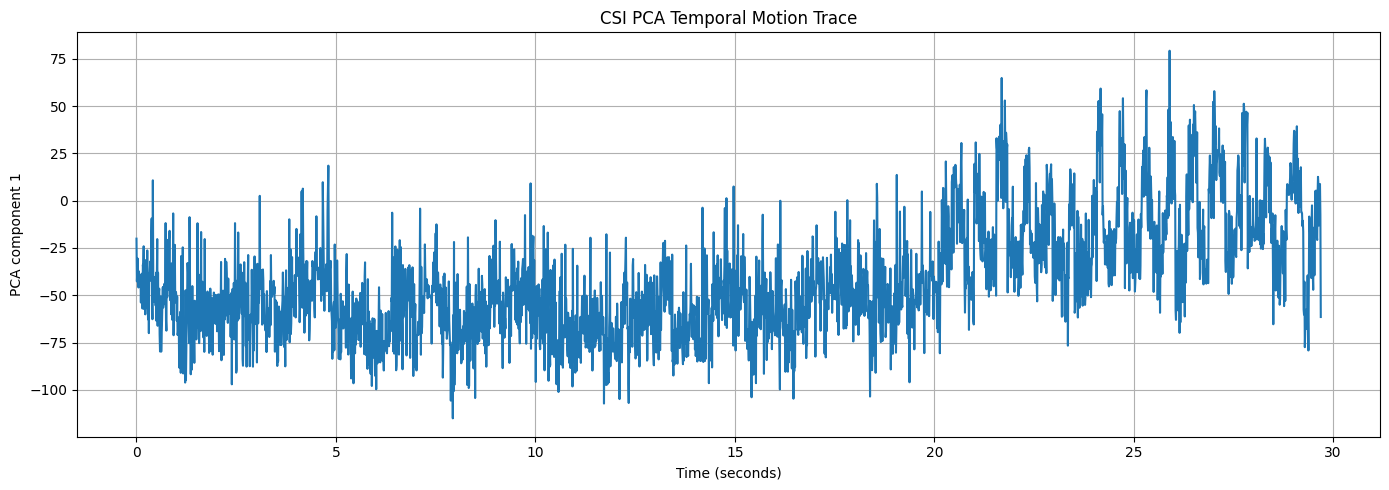

In [39]:
# ============================================================
# PCA TEMPORAL TRACE VISUALIZATION
# ============================================================

time = np.arange(
    len(trace)
) / CSI_FS

plt.figure(
    figsize=(14, 5)
)

plt.plot(
    time,
    trace
)

plt.xlabel(
    "Time (seconds)"
)

plt.ylabel(
    "PCA component 1"
)

plt.title(
    "CSI PCA Temporal Motion Trace"
)

plt.grid(True)

plt.tight_layout()

plt.show()

In [40]:
# ============================================================
# STFT
# ============================================================

def compute_stft(
    trace
):

    # --------------------------------------------------------
    # scipy is imported here so the rest of the notebook
    # remains lightweight until this stage.
    # --------------------------------------------------------

    from scipy.signal import stft

    frequencies, times, Zxx = stft(
        trace,
        fs=CSI_FS,
        window="hann",
        nperseg=N_PER_SEG,
        noverlap=N_OVERLAP,
        boundary=None
    )

    magnitude = np.abs(
        Zxx
    )

    return (
        frequencies,
        times,
        magnitude
    )


frequencies, times, magnitude = compute_stft(
    trace
)

print("=" * 60)
print("STFT")
print("=" * 60)

print(
    "Frequency bins:",
    len(frequencies)
)

print(
    "Time bins:",
    len(times)
)

print(
    "STFT shape:",
    magnitude.shape
)

print(
    "Frequency range:",
    frequencies.min(),
    "to",
    frequencies.max(),
    "Hz"
)

STFT
Frequency bins: 33
Time bins: 183
STFT shape: (33, 183)
Frequency range: 0.0 to 50.0 Hz


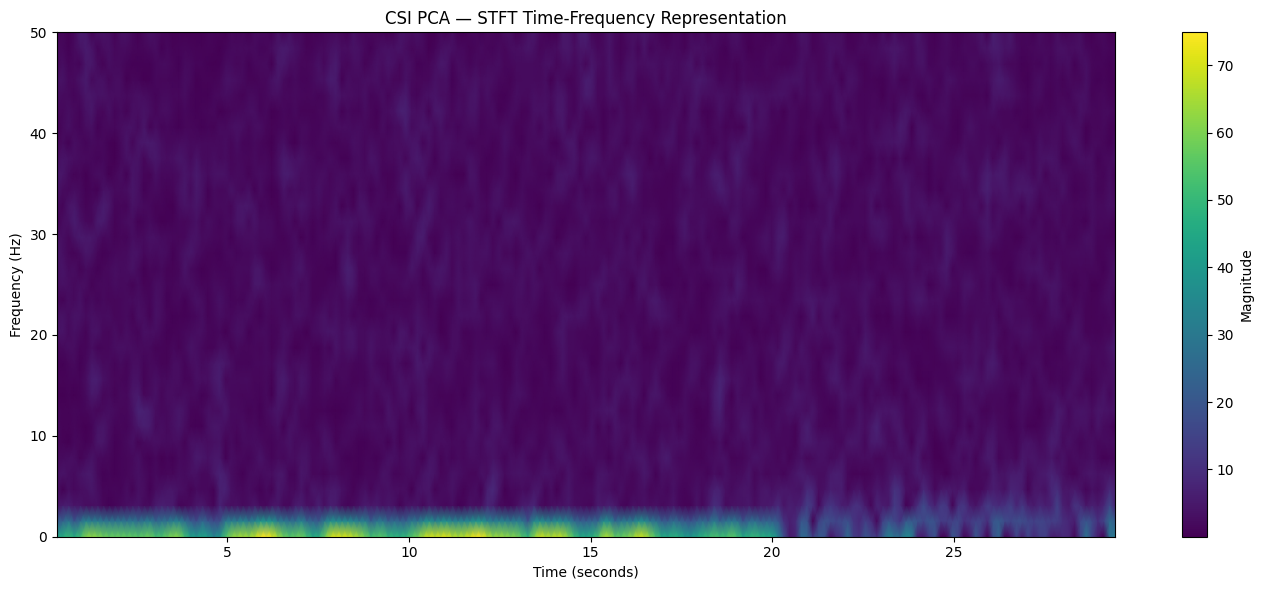

In [41]:
# ============================================================
# TIME-FREQUENCY REPRESENTATION
# ============================================================

plt.figure(
    figsize=(14, 6)
)

plt.pcolormesh(
    times,
    frequencies,
    magnitude,
    shading="gouraud"
)

plt.xlabel(
    "Time (seconds)"
)

plt.ylabel(
    "Frequency (Hz)"
)

plt.title(
    "CSI PCA — STFT Time-Frequency Representation"
)

plt.colorbar(
    label="Magnitude"
)

plt.tight_layout()

plt.show()

In [42]:
# ============================================================
# 30-FRAME WINDOW STFT
# ============================================================

def extract_window_trace(
    sequence_index,
    start_frame
):

    sequence = np.asarray(
        amplitude[sequence_index],
        dtype=np.float32
    )

    # Select exactly 30 frames
    window = sequence[
        start_frame:
        start_frame + WINDOW
    ]

    # (30, 3, 114, 10)
    window = np.transpose(
        window,
        (0, 3, 1, 2)
    )

    # (300, 342)
    window = window.reshape(
        WINDOW_SAMPLES,
        CSI_FEATURES
    )

    # PCA
    window_trace = ipca.transform(
        window
    )[:, 0]

    return window_trace


window_trace = extract_window_trace(
    train_sequences[0],
    0
)

print("=" * 60)
print("30-FRAME WINDOW")
print("=" * 60)

print(
    "Window trace:",
    window_trace.shape
)

assert window_trace.shape == (
    WINDOW_SAMPLES,
)

window_frequencies, window_times, window_magnitude = (
    compute_stft(
        window_trace
    )
)

print(
    "STFT:",
    window_magnitude.shape
)

30-FRAME WINDOW
Window trace: (300,)
STFT: (33, 16)


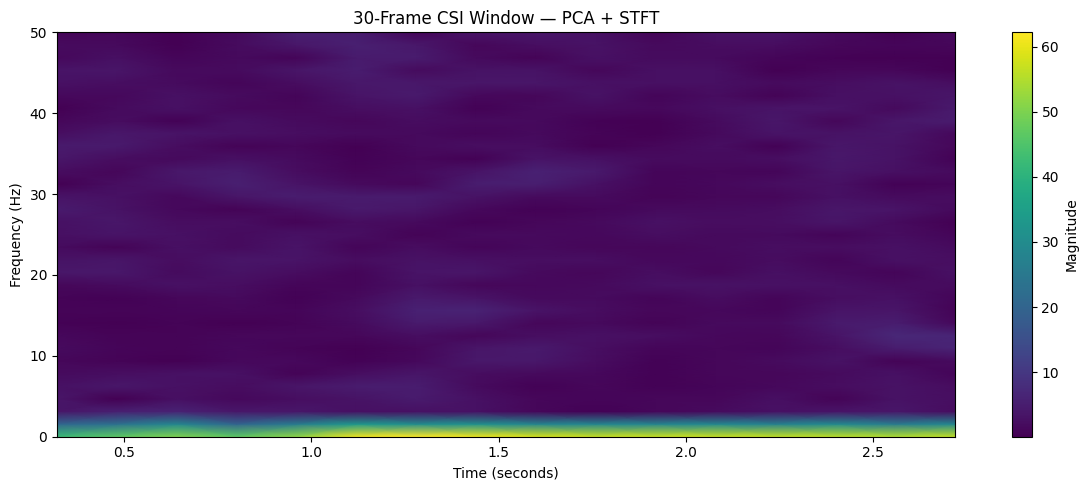

In [43]:
# ============================================================
# WINDOW TIME-FREQUENCY MAP
# ============================================================

plt.figure(
    figsize=(12, 5)
)

plt.pcolormesh(
    window_times,
    window_frequencies,
    window_magnitude,
    shading="gouraud"
)

plt.xlabel(
    "Time (seconds)"
)

plt.ylabel(
    "Frequency (Hz)"
)

plt.title(
    "30-Frame CSI Window — PCA + STFT"
)

plt.colorbar(
    label="Magnitude"
)

plt.tight_layout()

plt.show()

In [44]:
# ============================================================
# EXPERIMENT F — BUILD PCA + STFT DATASET
# ============================================================

from scipy.signal import stft

print("=" * 60)
print("BUILDING PCA + STFT DATASET")
print("=" * 60)


# ============================================================
# STFT FUNCTION
# ============================================================

def make_stft_representation(trace):

    frequencies, times, Zxx = stft(
        trace,
        fs=CSI_FS,
        window="hann",
        nperseg=N_PER_SEG,
        noverlap=N_OVERLAP,
        boundary=None
    )

    magnitude = np.abs(Zxx)

    # Log compression:
    # helps prevent very large amplitudes from dominating
    magnitude = np.log1p(magnitude)

    return magnitude.astype(
        np.float32
    )


# ============================================================
# NUMBER OF WINDOWS
# ============================================================

WINDOWS_PER_SEQUENCE = (
    (FRAMES_PER_SEQUENCE - WINDOW)
    // STRIDE
) + 1

print(
    "Windows per sequence:",
    WINDOWS_PER_SEQUENCE
)

assert WINDOWS_PER_SEQUENCE == 18


N_TRAIN = (
    len(train_sequences)
    * WINDOWS_PER_SEQUENCE
)

N_VAL = (
    len(val_sequences)
    * WINDOWS_PER_SEQUENCE
)

N_TEST = (
    len(test_sequences)
    * WINDOWS_PER_SEQUENCE
)

print(
    "Train windows:",
    N_TRAIN
)

print(
    "Validation windows:",
    N_VAL
)

print(
    "Test windows:",
    N_TEST
)

assert N_TRAIN == 3402
assert N_VAL == 486
assert N_TEST == 972


# ============================================================
# DETERMINE STFT SHAPE
# ============================================================

example_trace = extract_window_trace(
    train_sequences[0],
    0
)

example_stft = make_stft_representation(
    example_trace
)

FREQ_BINS, TIME_BINS = example_stft.shape

print()
print(
    "STFT representation:",
    example_stft.shape
)

print(
    "Frequency bins:",
    FREQ_BINS
)

print(
    "Time bins:",
    TIME_BINS
)


# ============================================================
# DATASET BUILDER
# ============================================================

def build_stft_dataset(
    sequence_indices,
    dataset_name
):

    n_samples = (
        len(sequence_indices)
        * WINDOWS_PER_SEQUENCE
    )

    output = np.zeros(
        (
            n_samples,
            FREQ_BINS,
            TIME_BINS
        ),
        dtype=np.float32
    )

    sequence_ids = np.zeros(
        n_samples,
        dtype=np.int32
    )

    window_starts = np.zeros(
        n_samples,
        dtype=np.int32
    )

    index = 0

    print()
    print(
        f"Building {dataset_name} dataset..."
    )

    for seq_count, seq in enumerate(
        sequence_indices,
        start=1
    ):

        # ----------------------------------------------------
        # PCA trace for entire sequence
        # ----------------------------------------------------

        full_trace = extract_pca_trace(
            seq
        )

        for start_frame in range(
            0,
            FRAMES_PER_SEQUENCE - WINDOW + 1,
            STRIDE
        ):

            start_sample = (
                start_frame
                * INNER_SAMPLES
            )

            end_sample = (
                start_sample
                + WINDOW_SAMPLES
            )

            window_trace = (
                full_trace[
                    start_sample:end_sample
                ]
            )

            representation = (
                make_stft_representation(
                    window_trace
                )
            )

            output[index] = representation

            sequence_ids[index] = seq

            window_starts[index] = start_frame

            index += 1

        if (
            seq_count == 1
            or seq_count % 20 == 0
            or seq_count == len(sequence_indices)
        ):

            print(
                f"Processed "
                f"{seq_count}/"
                f"{len(sequence_indices)} sequences"
            )

    print(
        f"{dataset_name} complete:",
        output.shape
    )

    return (
        output,
        sequence_ids,
        window_starts
    )


# ============================================================
# BUILD ALL THREE SPLITS
# ============================================================

train_stft, train_seq_ids, train_starts = (
    build_stft_dataset(
        train_sequences,
        "TRAIN"
    )
)

val_stft, val_seq_ids, val_starts = (
    build_stft_dataset(
        val_sequences,
        "VALIDATION"
    )
)

test_stft, test_seq_ids, test_starts = (
    build_stft_dataset(
        test_sequences,
        "TEST"
    )
)


# ============================================================
# FINAL SHAPE CHECK
# ============================================================

print()
print("=" * 60)
print("STFT DATASET SHAPES")
print("=" * 60)

print(
    "Train:",
    train_stft.shape
)

print(
    "Validation:",
    val_stft.shape
)

print(
    "Test:",
    test_stft.shape
)

assert train_stft.shape[0] == 3402
assert val_stft.shape[0] == 486
assert test_stft.shape[0] == 972

assert train_stft.shape[1:] == (
    FREQ_BINS,
    TIME_BINS
)

assert val_stft.shape[1:] == (
    FREQ_BINS,
    TIME_BINS
)

assert test_stft.shape[1:] == (
    FREQ_BINS,
    TIME_BINS
)

print()
print("Dataset shape validation: PASSED")

BUILDING PCA + STFT DATASET
Windows per sequence: 18
Train windows: 3402
Validation windows: 486
Test windows: 972

STFT representation: (33, 16)
Frequency bins: 33
Time bins: 16

Building TRAIN dataset...
Processed 1/189 sequences
Processed 20/189 sequences
Processed 40/189 sequences
Processed 60/189 sequences
Processed 80/189 sequences
Processed 100/189 sequences
Processed 120/189 sequences
Processed 140/189 sequences
Processed 160/189 sequences
Processed 180/189 sequences
Processed 189/189 sequences
TRAIN complete: (3402, 33, 16)

Building VALIDATION dataset...
Processed 1/27 sequences
Processed 20/27 sequences
Processed 27/27 sequences
VALIDATION complete: (486, 33, 16)

Building TEST dataset...
Processed 1/54 sequences
Processed 20/54 sequences
Processed 40/54 sequences
Processed 54/54 sequences
TEST complete: (972, 33, 16)

STFT DATASET SHAPES
Train: (3402, 33, 16)
Validation: (486, 33, 16)
Test: (972, 33, 16)

Dataset shape validation: PASSED


In [45]:
# ============================================================
# STFT DATA QUALITY CHECK
# ============================================================

print("=" * 60)
print("STFT DATA QUALITY")
print("=" * 60)

print(
    "Train min:",
    train_stft.min()
)

print(
    "Train max:",
    train_stft.max()
)

print(
    "Train mean:",
    train_stft.mean()
)

print(
    "Train std:",
    train_stft.std()
)

print()
print(
    "NaN:",
    np.isnan(train_stft).sum()
)

print(
    "+Inf:",
    np.isposinf(train_stft).sum()
)

print(
    "-Inf:",
    np.isneginf(train_stft).sum()
)

assert np.isfinite(
    train_stft
).all()

assert np.isfinite(
    val_stft
).all()

assert np.isfinite(
    test_stft
).all()

print()
print("Finite-value validation: PASSED")

STFT DATA QUALITY
Train min: 3.9144626e-05
Train max: 4.7327185
Train mean: 1.2317488
Train std: 0.64878094

NaN: 0
+Inf: 0
-Inf: 0

Finite-value validation: PASSED


In [46]:
# ============================================================
# STFT NORMALIZATION
# ============================================================

stft_mean = train_stft.mean(
    axis=(0, 1, 2),
    keepdims=True
)

stft_std = train_stft.std(
    axis=(0, 1, 2),
    keepdims=True
)

stft_std = np.maximum(
    stft_std,
    1e-6
)

train_stft_norm = (
    train_stft - stft_mean
) / stft_std

val_stft_norm = (
    val_stft - stft_mean
) / stft_std

test_stft_norm = (
    test_stft - stft_mean
) / stft_std


print("=" * 60)
print("STFT NORMALIZATION")
print("=" * 60)

print(
    "Training normalized mean:",
    train_stft_norm.mean()
)

print(
    "Training normalized std:",
    train_stft_norm.std()
)

print(
    "Validation mean:",
    val_stft_norm.mean()
)

print(
    "Test mean:",
    test_stft_norm.mean()
)

STFT NORMALIZATION
Training normalized mean: 4.9663845e-07
Training normalized std: 1.0
Validation mean: -0.0020431336
Test mean: -0.12827453


In [47]:
# ============================================================
# SAVE EXPERIMENT F DATASET
# ============================================================

F_DATA_DIR = os.path.join(
    ROOT,
    "data",
    "processed",
    "experiment_F"
)

os.makedirs(
    F_DATA_DIR,
    exist_ok=True
)


np.save(
    os.path.join(
        F_DATA_DIR,
        "train_stft.npy"
    ),
    train_stft_norm
)

np.save(
    os.path.join(
        F_DATA_DIR,
        "val_stft.npy"
    ),
    val_stft_norm
)

np.save(
    os.path.join(
        F_DATA_DIR,
        "test_stft.npy"
    ),
    test_stft_norm
)

np.save(
    os.path.join(
        F_DATA_DIR,
        "stft_mean.npy"
    ),
    stft_mean
)

np.save(
    os.path.join(
        F_DATA_DIR,
        "stft_std.npy"
    ),
    stft_std
)

np.save(
    os.path.join(
        F_DATA_DIR,
        "train_sequence_ids.npy"
    ),
    train_seq_ids
)

np.save(
    os.path.join(
        F_DATA_DIR,
        "val_sequence_ids.npy"
    ),
    val_seq_ids
)

np.save(
    os.path.join(
        F_DATA_DIR,
        "test_sequence_ids.npy"
    ),
    test_seq_ids
)

np.save(
    os.path.join(
        F_DATA_DIR,
        "train_window_starts.npy"
    ),
    train_starts
)

np.save(
    os.path.join(
        F_DATA_DIR,
        "val_window_starts.npy"
    ),
    val_starts
)

np.save(
    os.path.join(
        F_DATA_DIR,
        "test_window_starts.npy"
    ),
    test_starts
)

print("=" * 60)
print("EXPERIMENT F DATASET SAVED")
print("=" * 60)

print(
    F_DATA_DIR
)

EXPERIMENT F DATASET SAVED
C:\Users\ROHITH KANNA S\WiFiVision\data\processed\experiment_F


In [48]:
# ============================================================
# FINAL STFT DIMENSION CHECK
# ============================================================

print("=" * 60)
print("EXPERIMENT F — FINAL REPRESENTATION")
print("=" * 60)

print("Train STFT:", train_stft_norm.shape)
print("Val STFT  :", val_stft_norm.shape)
print("Test STFT :", test_stft_norm.shape)

print()
print("Frequency bins :", FREQ_BINS)
print("Time bins      :", TIME_BINS)

print()
print("Window duration:",
      WINDOW_SAMPLES / CSI_FS,
      "seconds")

print("STFT frequency resolution:",
      CSI_FS / N_PER_SEG,
      "Hz")

print()
print("Training distribution:")
print("Mean:", train_stft_norm.mean())
print("Std :", train_stft_norm.std())

print()
print("Validation distribution:")
print("Mean:", val_stft_norm.mean())
print("Std :", val_stft_norm.std())

print()
print("Test distribution:")
print("Mean:", test_stft_norm.mean())
print("Std :", test_stft_norm.std())

EXPERIMENT F — FINAL REPRESENTATION
Train STFT: (3402, 33, 16)
Val STFT  : (486, 33, 16)
Test STFT : (972, 33, 16)

Frequency bins : 33
Time bins      : 16

Window duration: 3.0 seconds
STFT frequency resolution: 1.5625 Hz

Training distribution:
Mean: 4.9663845e-07
Std : 1.0

Validation distribution:
Mean: -0.0020431336
Std : 1.0581006

Test distribution:
Mean: -0.12827453
Std : 0.96825135


Device: cpu

Pose shape: (270, 297, 17, 2)

DATASET
Train windows: 3402
Validation windows: 486
Test windows: 972

MODEL CHECK
Parameters: 13506

Input : (8, 33, 16)
Target: (8, 17, 2)
Output: (8, 17, 2)

Shape validation: PASSED

EXPERIMENT F — TRAINING
Epoch 01/30 | Train Loss: 0.023774 | Val Loss: 0.024682  -> Best model saved
Epoch 02/30 | Train Loss: 0.021836 | Val Loss: 0.024353  -> Best model saved
Epoch 03/30 | Train Loss: 0.021599 | Val Loss: 0.024386  -> No improvement (1/5)
Epoch 04/30 | Train Loss: 0.021323 | Val Loss: 0.025918  -> No improvement (2/5)
Epoch 05/30 | Train Loss: 0.021305 | Val Loss: 0.023965  -> Best model saved
Epoch 06/30 | Train Loss: 0.021190 | Val Loss: 0.024143  -> No improvement (1/5)
Epoch 07/30 | Train Loss: 0.021198 | Val Loss: 0.024080  -> No improvement (2/5)
Epoch 08/30 | Train Loss: 0.020972 | Val Loss: 0.023559  -> Best model saved
Epoch 09/30 | Train Loss: 0.020956 | Val Loss: 0.023925  -> No improvement (1/5)
Epoch 10/30 | Train Loss: 0.0209

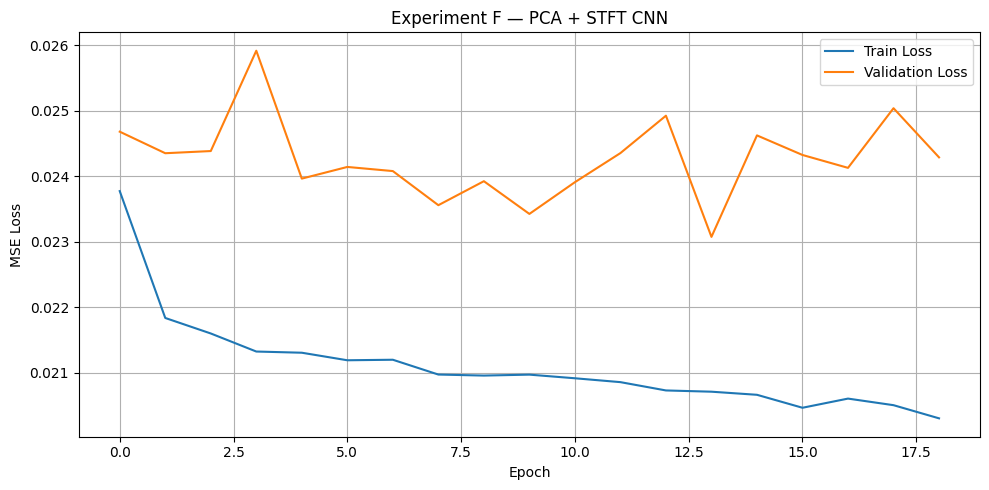


TEST OUTPUT
Predictions: (972, 17, 2)
Targets    : (972, 17, 2)

EXPERIMENT F — TEST EVALUATION
MPJPE: 0.024375

PCK:
@ 0.05: 85.69%
@ 0.10: 95.75%
@ 0.15: 98.52%
@ 0.20: 99.46%

Per-joint error:
Joint 01: 0.009041
Joint 02: 0.009173
Joint 03: 0.009165
Joint 04: 0.008510
Joint 05: 0.009112
Joint 06: 0.010648
Joint 07: 0.010482
Joint 08: 0.011322
Joint 09: 0.015165
Joint 10: 0.020006
Joint 11: 0.020122
Joint 12: 0.014285
Joint 13: 0.032975
Joint 14: 0.093503
Joint 15: 0.014771
Joint 16: 0.032287
Joint 17: 0.093806

FINAL COMPARISON
Amplitude baseline : 0.139277
Experiment F       : 0.024375

F vs baseline: -82.50%

RESULT: PCA + STFT IMPROVED over baseline.

Results saved to: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\experiment_F


In [49]:
# ============================================================
# EXPERIMENT F — PCA + STFT CNN → POSE
# ============================================================

import os
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# ============================================================
# CONFIG
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

EPOCHS = 30
BATCH_SIZE = 8
LEARNING_RATE = 1e-3
PATIENCE = 5

F_CHECKPOINT = os.path.join(
    ROOT,
    "models",
    "pca_stft_best.pt"
)

RESULT_DIR = os.path.join(
    ROOT,
    "data",
    "processed",
    "experiment_F"
)

os.makedirs(
    os.path.dirname(F_CHECKPOINT),
    exist_ok=True
)

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

print("Device:", DEVICE)


# ============================================================
# 1. TORCH DATASETS
# ============================================================

class STFTPoseDataset(torch.utils.data.Dataset):

    def __init__(
        self,
        stft_data,
        sequence_ids,
        window_starts,
        pose_data
    ):

        self.stft_data = stft_data
        self.sequence_ids = sequence_ids
        self.window_starts = window_starts
        self.pose_data = pose_data

    def __len__(self):

        return len(
            self.stft_data
        )

    def __getitem__(self, idx):

        x = self.stft_data[idx]

        seq_id = self.sequence_ids[idx]

        start_frame = self.window_starts[idx]

        # ----------------------------------------------------
        # Use the LAST pose frame of the 30-frame window.
        # This matches the baseline's final-frame prediction.
        # ----------------------------------------------------

        pose = self.pose_data[
            seq_id,
            start_frame + WINDOW - 1
        ]

        return (
            torch.tensor(
                x,
                dtype=torch.float32
            ),
            torch.tensor(
                pose,
                dtype=torch.float32
            )
        )


# ============================================================
# LOAD POSE
# ============================================================

POSE_PATH = os.path.join(
    ROOT,
    "data",
    "processed",
    "mmfi_sequence",
    "pose.npy"
)

pose_data = np.load(
    POSE_PATH,
    mmap_mode="r"
)

print()
print(
    "Pose shape:",
    pose_data.shape
)


# ============================================================
# CREATE DATASETS
# ============================================================

train_dataset = STFTPoseDataset(
    train_stft_norm,
    train_seq_ids,
    train_starts,
    pose_data
)

val_dataset = STFTPoseDataset(
    val_stft_norm,
    val_seq_ids,
    val_starts,
    pose_data
)

test_dataset = STFTPoseDataset(
    test_stft_norm,
    test_seq_ids,
    test_starts,
    pose_data
)


# ============================================================
# DATA LOADERS
# ============================================================

train_loader_F = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader_F = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader_F = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)


print()
print("=" * 60)
print("DATASET")
print("=" * 60)

print(
    "Train windows:",
    len(train_dataset)
)

print(
    "Validation windows:",
    len(val_dataset)
)

print(
    "Test windows:",
    len(test_dataset)
)


# ============================================================
# 2. MODEL
# ============================================================

class STFTPoseCNN(nn.Module):

    def __init__(self):

        super().__init__()

        # ----------------------------------------------------
        # STFT INPUT
        #
        # (B, 1, 33, 16)
        # ----------------------------------------------------

        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                16,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(16),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            ),

            # 33 x 16
            # ↓
            # 16 x 8


            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            ),

            # 16 x 8
            # ↓
            # 8 x 4


            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )

        # ----------------------------------------------------
        # POSE HEAD
        # ----------------------------------------------------

        self.head = nn.Sequential(

            nn.Linear(
                32,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                34
            )
        )


    def forward(self, x):

        # ----------------------------------------------------
        # Input:
        #
        # (B, 33, 16)
        # ----------------------------------------------------

        x = x.unsqueeze(1)

        # (B, 1, 33, 16)

        x = self.features(x)

        # (B, 32, 1, 1)

        x = x.flatten(1)

        # (B, 32)

        x = self.head(x)

        # (B, 34)

        x = x.reshape(
            x.shape[0],
            17,
            2
        )

        return x


# ============================================================
# 3. MODEL CHECK
# ============================================================

model_F = STFTPoseCNN().to(
    DEVICE
)

parameters_F = sum(
    p.numel()
    for p in model_F.parameters()
    if p.requires_grad
)

print()
print("=" * 60)
print("MODEL CHECK")
print("=" * 60)

print(
    "Parameters:",
    parameters_F
)


# ============================================================
# SHAPE CHECK
# ============================================================

sample_x, sample_y = next(
    iter(train_loader_F)
)

sample_x = sample_x.to(
    DEVICE
)

sample_y = sample_y.to(
    DEVICE
)

with torch.no_grad():

    sample_output = model_F(
        sample_x
    )

print()
print(
    "Input :",
    tuple(sample_x.shape)
)

print(
    "Target:",
    tuple(sample_y.shape)
)

print(
    "Output:",
    tuple(sample_output.shape)
)

assert tuple(sample_output.shape) == (
    sample_x.shape[0],
    17,
    2
)

print()
print("Shape validation: PASSED")


# ============================================================
# 4. TRAINING
# ============================================================

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model_F.parameters(),
    lr=LEARNING_RATE
)

best_val_loss = float("inf")
best_state = None
patience_counter = 0

train_losses = []
val_losses = []


print()
print("=" * 60)
print("EXPERIMENT F — TRAINING")
print("=" * 60)


for epoch in range(
    1,
    EPOCHS + 1
):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model_F.train()

    train_loss_sum = 0.0
    train_count = 0

    for x, y in train_loader_F:

        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()

        prediction = model_F(x)

        loss = criterion(
            prediction,
            y
        )

        loss.backward()

        optimizer.step()

        batch_size = x.size(0)

        train_loss_sum += (
            loss.item()
            * batch_size
        )

        train_count += batch_size

    train_loss = (
        train_loss_sum /
        train_count
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model_F.eval()

    val_loss_sum = 0.0
    val_count = 0

    with torch.no_grad():

        for x, y in val_loader_F:

            x = x.to(DEVICE)
            y = y.to(DEVICE)

            prediction = model_F(x)

            loss = criterion(
                prediction,
                y
            )

            batch_size = x.size(0)

            val_loss_sum += (
                loss.item()
                * batch_size
            )

            val_count += batch_size

    val_loss = (
        val_loss_sum /
        val_count
    )

    train_losses.append(
        train_loss
    )

    val_losses.append(
        val_loss
    )


    # --------------------------------------------------------
    # LOGGING
    # --------------------------------------------------------

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}",
        end=""
    )


    # --------------------------------------------------------
    # CHECKPOINT
    # --------------------------------------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        patience_counter = 0

        best_state = copy.deepcopy(
            model_F.state_dict()
        )

        torch.save(
            {
                "model_state_dict":
                    model_F.state_dict(),

                "val_loss":
                    best_val_loss,

                "epoch":
                    epoch,

                "parameters":
                    parameters_F
            },
            F_CHECKPOINT
        )

        print(
            "  -> Best model saved"
        )

    else:

        patience_counter += 1

        print(
            f"  -> No improvement "
            f"({patience_counter}/{PATIENCE})"
        )


    if patience_counter >= PATIENCE:

        print()
        print("Early stopping.")
        break


# ============================================================
# 5. RESTORE BEST MODEL
# ============================================================

model_F.load_state_dict(
    best_state
)

model_F.eval()

print()
print("=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

print(
    "Best validation loss:",
    best_val_loss
)

print(
    "Checkpoint:",
    F_CHECKPOINT
)


# ============================================================
# 6. TRAINING CURVE
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "MSE Loss"
)

plt.title(
    "Experiment F — PCA + STFT CNN"
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 7. TEST EVALUATION
# ============================================================

predictions_list = []
targets_list = []

with torch.no_grad():

    for x, y in test_loader_F:

        x = x.to(DEVICE)

        prediction = model_F(x)

        predictions_list.append(
            prediction.cpu().numpy()
        )

        targets_list.append(
            y.numpy()
        )


predictions = np.concatenate(
    predictions_list,
    axis=0
)

targets = np.concatenate(
    targets_list,
    axis=0
)


print()
print("=" * 60)
print("TEST OUTPUT")
print("=" * 60)

print(
    "Predictions:",
    predictions.shape
)

print(
    "Targets    :",
    targets.shape
)


# ============================================================
# 8. DENORMALIZE POSE
# ============================================================

predictions = (
    predictions
    * pose_std
) + pose_mean

targets = (
    targets
    * pose_std
) + pose_mean


# ============================================================
# 9. MPJPE
# ============================================================

errors = np.linalg.norm(
    predictions - targets,
    axis=2
)

mpjpe_F = float(
    errors.mean()
)


print()
print("=" * 60)
print("EXPERIMENT F — TEST EVALUATION")
print("=" * 60)

print(
    f"MPJPE: {mpjpe_F:.6f}"
)


# ============================================================
# 10. PCK
# ============================================================

print()
print("PCK:")

for threshold in [
    0.05,
    0.10,
    0.15,
    0.20
]:

    pck = (
        errors <= threshold
    ).mean() * 100

    print(
        f"@ {threshold:.2f}: "
        f"{pck:.2f}%"
    )


# ============================================================
# 11. PER-JOINT ERROR
# ============================================================

joint_errors = errors.mean(
    axis=0
)

print()
print("Per-joint error:")

for i, error in enumerate(
    joint_errors,
    start=1
):

    print(
        f"Joint {i:02d}: "
        f"{error:.6f}"
    )


# ============================================================
# 12. SAVE RESULTS
# ============================================================

np.save(
    os.path.join(
        RESULT_DIR,
        "predictions.npy"
    ),
    predictions
)

np.save(
    os.path.join(
        RESULT_DIR,
        "targets.npy"
    ),
    targets
)

np.save(
    os.path.join(
        RESULT_DIR,
        "errors.npy"
    ),
    errors
)


# ============================================================
# 13. FINAL COMPARISON
# ============================================================

baseline_mpjpe = 0.139277

change_F = (
    (
        mpjpe_F -
        baseline_mpjpe
    )
    /
    baseline_mpjpe
) * 100


print()
print("=" * 60)
print("FINAL COMPARISON")
print("=" * 60)

print(
    f"Amplitude baseline : "
    f"{baseline_mpjpe:.6f}"
)

print(
    f"Experiment F       : "
    f"{mpjpe_F:.6f}"
)

print()
print(
    f"F vs baseline: "
    f"{change_F:+.2f}%"
)

if mpjpe_F < baseline_mpjpe:

    print()
    print(
        "RESULT: PCA + STFT "
        "IMPROVED over baseline."
    )

else:

    print()
    print(
        "RESULT: PCA + STFT "
        "DID NOT improve baseline."
    )

print()
print(
    "Results saved to:",
    RESULT_DIR
)

In [50]:
# ============================================================
# EXPERIMENT F — CORRECTED TRAINING
# PCA + STFT CNN
# ============================================================

import os
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# ============================================================
# CONFIG
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

EPOCHS = 30
BATCH_SIZE = 8
LEARNING_RATE = 1e-3
PATIENCE = 5

F_CHECKPOINT = os.path.join(
    ROOT,
    "models",
    "pca_stft_corrected_best.pt"
)

RESULT_DIR = os.path.join(
    ROOT,
    "data",
    "processed",
    "experiment_F_corrected"
)

os.makedirs(
    os.path.dirname(F_CHECKPOINT),
    exist_ok=True
)

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)


# ============================================================
# DATASET
# ============================================================

class STFTPoseDatasetCorrected(
    torch.utils.data.Dataset
):

    def __init__(
        self,
        stft_data,
        sequence_ids,
        window_starts,
        pose_data,
        pose_mean,
        pose_std
    ):

        self.stft_data = stft_data
        self.sequence_ids = sequence_ids
        self.window_starts = window_starts
        self.pose_data = pose_data

        self.pose_mean = pose_mean
        self.pose_std = pose_std

    def __len__(self):

        return len(
            self.stft_data
        )

    def __getitem__(self, idx):

        x = self.stft_data[idx]

        seq_id = self.sequence_ids[idx]

        start_frame = self.window_starts[idx]

        target_frame = (
            start_frame
            + WINDOW
            - 1
        )

        # ----------------------------------------------------
        # RAW POSE
        # ----------------------------------------------------

        pose = np.asarray(
            self.pose_data[
                seq_id,
                target_frame
            ],
            dtype=np.float32
        )

        # ----------------------------------------------------
        # CRITICAL:
        # NORMALIZE TARGET EXACTLY LIKE BASELINE
        # ----------------------------------------------------

        pose = (
            pose - self.pose_mean
        ) / self.pose_std

        return (
            torch.tensor(
                x,
                dtype=torch.float32
            ),
            torch.tensor(
                pose,
                dtype=torch.float32
            )
        )


# ============================================================
# DATASETS
# ============================================================

train_dataset_F = STFTPoseDatasetCorrected(
    train_stft_norm,
    train_seq_ids,
    train_starts,
    pose_data,
    pose_mean,
    pose_std
)

val_dataset_F = STFTPoseDatasetCorrected(
    val_stft_norm,
    val_seq_ids,
    val_starts,
    pose_data,
    pose_mean,
    pose_std
)

test_dataset_F = STFTPoseDatasetCorrected(
    test_stft_norm,
    test_seq_ids,
    test_starts,
    pose_data,
    pose_mean,
    pose_std
)


# ============================================================
# LOADERS
# ============================================================

train_loader_F = torch.utils.data.DataLoader(
    train_dataset_F,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader_F = torch.utils.data.DataLoader(
    val_dataset_F,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader_F = torch.utils.data.DataLoader(
    test_dataset_F,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)


print("Device:", DEVICE)

print()
print("=" * 60)
print("CORRECTED DATASET")
print("=" * 60)

print(
    "Train windows:",
    len(train_dataset_F)
)

print(
    "Validation windows:",
    len(val_dataset_F)
)

print(
    "Test windows:",
    len(test_dataset_F)
)


# ============================================================
# 1. VERIFY TARGET NORMALIZATION
# ============================================================

_, sample_target = train_dataset_F[0]

print()
print(
    "Sample normalized target:"
)

print(
    sample_target
)

print(
    "Target mean:",
    sample_target.numpy().mean()
)

print(
    "Target std:",
    sample_target.numpy().std()
)


# ============================================================
# 2. MODEL
# ============================================================

class STFTPoseCNNCorrected(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                16,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(16),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            ),

            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            ),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )

        self.head = nn.Sequential(

            nn.Linear(
                32,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                34
            )
        )

    def forward(self, x):

        # (B, 33, 16)

        x = x.unsqueeze(1)

        # (B, 1, 33, 16)

        x = self.features(x)

        # (B, 32, 1, 1)

        x = x.flatten(1)

        # (B, 32)

        x = self.head(x)

        # (B, 34)

        x = x.reshape(
            x.shape[0],
            17,
            2
        )

        return x


# ============================================================
# 3. MODEL CHECK
# ============================================================

model_F = STFTPoseCNNCorrected().to(
    DEVICE
)

parameters_F = sum(
    p.numel()
    for p in model_F.parameters()
    if p.requires_grad
)

print()
print("=" * 60)
print("MODEL CHECK")
print("=" * 60)

print(
    "Parameters:",
    parameters_F
)


# ============================================================
# 4. SHAPE CHECK
# ============================================================

sample_x, sample_y = next(
    iter(train_loader_F)
)

sample_x = sample_x.to(
    DEVICE
)

sample_y = sample_y.to(
    DEVICE
)

with torch.no_grad():

    sample_output = model_F(
        sample_x
    )

print()
print(
    "Input :",
    tuple(sample_x.shape)
)

print(
    "Target:",
    tuple(sample_y.shape)
)

print(
    "Output:",
    tuple(sample_output.shape)
)

assert tuple(sample_output.shape) == (
    sample_x.shape[0],
    17,
    2
)

print()
print("Shape validation: PASSED")


# ============================================================
# 5. TRAINING
# ============================================================

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model_F.parameters(),
    lr=LEARNING_RATE
)

best_val_loss = float("inf")
best_state = None
patience_counter = 0

train_losses = []
val_losses = []


print()
print("=" * 60)
print("CORRECTED EXPERIMENT F — TRAINING")
print("=" * 60)


for epoch in range(
    1,
    EPOCHS + 1
):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model_F.train()

    train_loss_sum = 0.0
    train_count = 0

    for x, y in train_loader_F:

        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()

        prediction = model_F(x)

        loss = criterion(
            prediction,
            y
        )

        loss.backward()

        optimizer.step()

        batch_size = x.size(0)

        train_loss_sum += (
            loss.item()
            * batch_size
        )

        train_count += batch_size

    train_loss = (
        train_loss_sum
        / train_count
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model_F.eval()

    val_loss_sum = 0.0
    val_count = 0

    with torch.no_grad():

        for x, y in val_loader_F:

            x = x.to(DEVICE)
            y = y.to(DEVICE)

            prediction = model_F(x)

            loss = criterion(
                prediction,
                y
            )

            batch_size = x.size(0)

            val_loss_sum += (
                loss.item()
                * batch_size
            )

            val_count += batch_size

    val_loss = (
        val_loss_sum
        / val_count
    )

    train_losses.append(
        train_loss
    )

    val_losses.append(
        val_loss
    )


    # --------------------------------------------------------
    # REPORT
    # --------------------------------------------------------

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}",
        end=""
    )


    # --------------------------------------------------------
    # CHECKPOINT
    # --------------------------------------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        patience_counter = 0

        best_state = copy.deepcopy(
            model_F.state_dict()
        )

        torch.save(
            {
                "model_state_dict":
                    model_F.state_dict(),

                "val_loss":
                    best_val_loss,

                "epoch":
                    epoch,

                "parameters":
                    parameters_F
            },
            F_CHECKPOINT
        )

        print(
            "  -> Best model saved"
        )

    else:

        patience_counter += 1

        print(
            f"  -> No improvement "
            f"({patience_counter}/{PATIENCE})"
        )


    if patience_counter >= PATIENCE:

        print()
        print("Early stopping.")
        break


# ============================================================
# 6. RESTORE BEST MODEL
# ============================================================

model_F.load_state_dict(
    best_state
)

model_F.eval()

print()
print("=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

print(
    "Best validation loss:",
    best_val_loss
)

print(
    "Checkpoint:",
    F_CHECKPOINT
)


# ============================================================
# 7. TEST
# ============================================================

predictions_list = []
targets_list = []

with torch.no_grad():

    for x, y in test_loader_F:

        x = x.to(DEVICE)

        prediction = model_F(x)

        predictions_list.append(
            prediction.cpu().numpy()
        )

        targets_list.append(
            y.numpy()
        )


predictions_normalized = np.concatenate(
    predictions_list,
    axis=0
)

targets_normalized = np.concatenate(
    targets_list,
    axis=0
)


print()
print("=" * 60)
print("TEST OUTPUT")
print("=" * 60)

print(
    "Predictions:",
    predictions_normalized.shape
)

print(
    "Targets    :",
    targets_normalized.shape
)


# ============================================================
# 8. DENORMALIZE EXACTLY ONCE
# ============================================================

predictions = (
    predictions_normalized
    * pose_std
) + pose_mean

targets = (
    targets_normalized
    * pose_std
) + pose_mean


# ============================================================
# 9. MPJPE
# ============================================================

errors = np.linalg.norm(
    predictions - targets,
    axis=2
)

mpjpe_F = float(
    errors.mean()
)


print()
print("=" * 60)
print("CORRECTED EXPERIMENT F — TEST")
print("=" * 60)

print(
    f"MPJPE: {mpjpe_F:.6f}"
)


# ============================================================
# 10. PCK
# ============================================================

print()
print("PCK:")

for threshold in [
    0.05,
    0.10,
    0.15,
    0.20
]:

    pck = (
        errors <= threshold
    ).mean() * 100

    print(
        f"@ {threshold:.2f}: "
        f"{pck:.2f}%"
    )


# ============================================================
# 11. PER-JOINT ERROR
# ============================================================

joint_errors = errors.mean(
    axis=0
)

print()
print("Per-joint error:")

for i, error in enumerate(
    joint_errors,
    start=1
):

    print(
        f"Joint {i:02d}: "
        f"{error:.6f}"
    )


# ============================================================
# 12. SAVE
# ============================================================

np.save(
    os.path.join(
        RESULT_DIR,
        "predictions.npy"
    ),
    predictions
)

np.save(
    os.path.join(
        RESULT_DIR,
        "targets.npy"
    ),
    targets
)

np.save(
    os.path.join(
        RESULT_DIR,
        "errors.npy"
    ),
    errors
)


# ============================================================
# 13. BASELINE COMPARISON
# ============================================================

baseline_mpjpe = 0.139277

change_F = (
    (
        mpjpe_F
        - baseline_mpjpe
    )
    /
    baseline_mpjpe
) * 100


print()
print("=" * 60)
print("FINAL COMPARISON")
print("=" * 60)

print(
    f"Amplitude baseline : "
    f"{baseline_mpjpe:.6f}"
)

print(
    f"Corrected F        : "
    f"{mpjpe_F:.6f}"
)

print()
print(
    f"F vs baseline: "
    f"{change_F:+.2f}%"
)

if mpjpe_F < baseline_mpjpe:

    print()
    print(
        "RESULT: PCA + STFT "
        "IMPROVED over baseline."
    )

else:

    print()
    print(
        "RESULT: PCA + STFT "
        "DID NOT improve baseline."
    )

print()
print(
    "Results saved to:",
    RESULT_DIR
)

Device: cpu

CORRECTED DATASET
Train windows: 3402
Validation windows: 486
Test windows: 972

Sample normalized target:
tensor([[ 0.6723, -0.5820],
        [ 0.7552, -0.9955],
        [ 0.3909, -1.3780],
        [ 0.4675, -1.2115],
        [ 0.5774, -0.1492],
        [ 0.1033, -0.0575],
        [-0.2001,  0.1286],
        [ 0.7612, -0.5950],
        [ 0.8092, -0.5640],
        [ 0.8414, -0.6227],
        [ 0.8270, -0.7632],
        [ 0.6333, -0.3639],
        [ 0.4799,  0.1119],
        [-0.4260, -0.5767],
        [ 0.8527, -0.6581],
        [ 0.7955, -0.0488],
        [ 1.3617, -0.6416]])
Target mean: 0.021629348
Target std: 0.68857336

MODEL CHECK
Parameters: 13506

Input : (8, 33, 16)
Target: (8, 17, 2)
Output: (8, 17, 2)

Shape validation: PASSED

CORRECTED EXPERIMENT F — TRAINING
Epoch 01/30 | Train Loss: 0.996960 | Val Loss: 1.149276  -> Best model saved
Epoch 02/30 | Train Loss: 0.978754 | Val Loss: 1.144350  -> Best model saved
Epoch 03/30 | Train Loss: 0.970677 | Val Loss: 1.1

In [ ]:
# ============================================================
# EXPERIMENT G — TOPOLOGY-AWARE GRAPH DECODER
# CORRECTED VERSION
# ============================================================

import os
import copy
import numpy as np
import torch
import torch.nn as nn


# ============================================================
# CONFIG
# ============================================================

ROOT = r"C:\Users\ROHITH KANNA S\WiFiVision"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

EPOCHS = 30
BATCH_SIZE = 8
LEARNING_RATE = 1e-3
PATIENCE = 5

WINDOW = 30
STRIDE = 15

CHECKPOINT = os.path.join(
    ROOT,
    "models",
    "topology_graph_best.pt"
)

RESULT_DIR = os.path.join(
    ROOT,
    "data",
    "processed",
    "experiment_G"
)

os.makedirs(
    os.path.dirname(CHECKPOINT),
    exist_ok=True
)

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

print("Device:", DEVICE)


# ============================================================
# PATHS
# ============================================================

CSI_PATH = os.path.join(
    ROOT,
    "data",
    "processed",
    "mmfi_calibrated",
    "amplitude_clean.npy"
)

POSE_PATH = os.path.join(
    ROOT,
    "data",
    "processed",
    "mmfi_sequence",
    "pose.npy"
)

SUBJECT_PATH = os.path.join(
    ROOT,
    "data",
    "processed",
    "mmfi_sequence",
    "subject.npy"
)

NORM_DIR = os.path.join(
    ROOT,
    "data",
    "processed",
    "baseline_split"
)

POSE_MEAN_PATH = os.path.join(
    NORM_DIR,
    "pose_mean.npy"
)

POSE_STD_PATH = os.path.join(
    NORM_DIR,
    "pose_std.npy"
)


# ============================================================
# LOAD DATA
# ============================================================

amplitude = np.load(
    CSI_PATH,
    mmap_mode="r"
)

pose = np.load(
    POSE_PATH,
    mmap_mode="r"
)

subject = np.load(
    SUBJECT_PATH
)

pose_mean = np.load(
    POSE_MEAN_PATH
)

pose_std = np.load(
    POSE_STD_PATH
)


print()
print("=" * 60)
print("DATA")
print("=" * 60)

print(
    "Amplitude:",
    amplitude.shape
)

print(
    "Pose:",
    pose.shape
)

print(
    "Subjects:",
    subject.shape
)

print(
    "Pose mean:",
    pose_mean.shape
)

print(
    "Pose std:",
    pose_std.shape
)


# ============================================================
# BASIC VALIDATION
# ============================================================

assert amplitude.shape == (
    270,
    297,
    3,
    114,
    10
)

assert pose.shape == (
    270,
    297,
    17,
    2
)

assert subject.shape == (
    270,
)

print()
print("Data validation: PASSED")


# ============================================================
# SUBJECT SPLIT
# ============================================================

TRAIN_SUBJECTS = np.array(
    [1, 2, 3, 4, 5, 6, 7]
)

VAL_SUBJECTS = np.array(
    [8]
)

TEST_SUBJECTS = np.array(
    [9, 10]
)


train_sequences = np.where(
    np.isin(
        subject,
        TRAIN_SUBJECTS
    )
)[0]

val_sequences = np.where(
    np.isin(
        subject,
        VAL_SUBJECTS
    )
)[0]

test_sequences = np.where(
    np.isin(
        subject,
        TEST_SUBJECTS
    )
)[0]


print()
print("=" * 60)
print("SUBJECT SPLIT")
print("=" * 60)

print(
    "Train sequences:",
    len(train_sequences)
)

print(
    "Validation sequences:",
    len(val_sequences)
)

print(
    "Test sequences:",
    len(test_sequences)
)

assert len(train_sequences) == 189
assert len(val_sequences) == 27
assert len(test_sequences) == 54


# ============================================================
# BUILD WINDOWS
# ============================================================

WINDOWS_PER_SEQUENCE = (
    (297 - WINDOW)
    // STRIDE
) + 1


def build_windows(
    sequence_indices
):

    windows = []

    for seq in sequence_indices:

        for start in range(
            0,
            297 - WINDOW + 1,
            STRIDE
        ):

            windows.append(
                (
                    int(seq),
                    int(start)
                )
            )

    return windows


train_windows = build_windows(
    train_sequences
)

val_windows = build_windows(
    val_sequences
)

test_windows = build_windows(
    test_sequences
)


print()
print("=" * 60)
print("WINDOWS")
print("=" * 60)

print(
    "Train:",
    len(train_windows)
)

print(
    "Validation:",
    len(val_windows)
)

print(
    "Test:",
    len(test_windows)
)

assert len(train_windows) == 3402
assert len(val_windows) == 486
assert len(test_windows) == 972


# ============================================================
# DATASET
# ============================================================

class CSIWindowDataset(
    torch.utils.data.Dataset
):

    def __init__(
        self,
        windows
    ):

        self.windows = windows

    def __len__(
        self
    ):

        return len(
            self.windows
        )

    def __getitem__(
        self,
        index
    ):

        seq, start = self.windows[
            index
        ]

        # ----------------------------------------------------
        # IMPORTANT FIX
        #
        # amplitude is memory-mapped with mmap_mode="r",
        # therefore the resulting NumPy view is READ-ONLY.
        #
        # .copy() creates a writable array before PyTorch
        # converts it into a tensor.
        # ----------------------------------------------------

        x = np.array(
            amplitude[
                seq,
                start:start + WINDOW
            ],
            dtype=np.float32,
            copy=True
        )

        # ----------------------------------------------------
        # Final frame of the 30-frame window
        # ----------------------------------------------------

        target_frame = (
            start
            + WINDOW
            - 1
        )

        # ----------------------------------------------------
        # Copy pose as well
        # ----------------------------------------------------

        y = np.array(
            pose[
                seq,
                target_frame
            ],
            dtype=np.float32,
            copy=True
        )

        # ----------------------------------------------------
        # Normalize pose exactly like baseline
        # ----------------------------------------------------

        y = (
            y - pose_mean
        ) / pose_std

        y = np.asarray(
            y,
            dtype=np.float32
        )

        return (
            torch.from_numpy(x),
            torch.from_numpy(y)
        )


# ============================================================
# DATASETS
# ============================================================

train_dataset = CSIWindowDataset(
    train_windows
)

val_dataset = CSIWindowDataset(
    val_windows
)

test_dataset = CSIWindowDataset(
    test_windows
)


# ============================================================
# LOADERS
# ============================================================

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)


print()
print("=" * 60)
print("DATASET")
print("=" * 60)

print(
    "Train windows:",
    len(train_dataset)
)

print(
    "Validation windows:",
    len(val_dataset)
)

print(
    "Test windows:",
    len(test_dataset)
)


# ============================================================
# GRAPH TOPOLOGY
# ============================================================

# COCO-17 topology:
#
# 0  Nose
# 1  Left Eye
# 2  Right Eye
# 3  Left Ear
# 4  Right Ear
# 5  Left Shoulder
# 6  Right Shoulder
# 7  Left Elbow
# 8  Right Elbow
# 9  Left Wrist
# 10 Right Wrist
# 11 Left Hip
# 12 Right Hip
# 13 Left Knee
# 14 Right Knee
# 15 Left Ankle
# 16 Right Ankle

EDGES = [

    (0, 1),
    (0, 2),

    (1, 3),
    (2, 4),

    (5, 6),

    (5, 7),
    (7, 9),

    (6, 8),
    (8, 10),

    (5, 11),
    (6, 12),

    (11, 12),

    (11, 13),
    (13, 15),

    (12, 14),
    (14, 16)
]


# ============================================================
# ADJACENCY MATRIX
# ============================================================

A = np.eye(
    17,
    dtype=np.float32
)

for i, j in EDGES:

    A[i, j] = 1.0
    A[j, i] = 1.0


# Row normalization

A = A / A.sum(
    axis=1,
    keepdims=True
)


A = torch.tensor(
    A,
    dtype=torch.float32,
    device=DEVICE
)


print()
print("=" * 60)
print("GRAPH")
print("=" * 60)

print(
    "Joints:",
    17
)

print(
    "Edges:",
    len(EDGES)
)

print(
    "Adjacency:",
    tuple(A.shape)
)


# ============================================================
# GRAPH CONVOLUTION
# ============================================================

class GraphConv(
    nn.Module
):

    def __init__(
        self,
        in_features,
        out_features
    ):

        super().__init__()

        self.linear = nn.Linear(
            in_features,
            out_features
        )

    def forward(
        self,
        x,
        adjacency
    ):

        # x:
        # (B, 17, C)

        x = torch.matmul(
            adjacency,
            x
        )

        x = self.linear(
            x
        )

        return x


# ============================================================
# FRAME CNN
# ============================================================

class CSIFrameCNN(
    nn.Module
):

    def __init__(
        self
    ):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=3,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(
                16
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            ),

            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(
                32
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            ),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )

    def forward(
        self,
        x
    ):

        x = self.features(
            x
        )

        x = x.flatten(
            1
        )

        return x


# ============================================================
# TOPOLOGY-AWARE MODEL
# ============================================================

class TopologyAwareCSI2Pose(
    nn.Module
):

    def __init__(
        self
    ):

        super().__init__()

        # ----------------------------------------------------
        # SAME FRAME CNN AS BASELINE
        # ----------------------------------------------------

        self.frame_cnn = CSIFrameCNN()

        # ----------------------------------------------------
        # SAME GRU AS BASELINE
        # ----------------------------------------------------

        self.gru = nn.GRU(
            input_size=32,
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )

        # ----------------------------------------------------
        # GLOBAL FEATURE → 17 JOINT TOKENS
        # ----------------------------------------------------

        self.joint_projection = nn.Linear(
            64,
            17 * 32
        )

        # ----------------------------------------------------
        # JOINT IDENTITY
        # ----------------------------------------------------

        self.joint_embedding = nn.Parameter(
            torch.randn(
                17,
                32
            ) * 0.02
        )

        # ----------------------------------------------------
        # GRAPH CONVOLUTIONS
        # ----------------------------------------------------

        self.gcn1 = GraphConv(
            32,
            32
        )

        self.gcn2 = GraphConv(
            32,
            32
        )

        # ----------------------------------------------------
        # GLOBAL JOINT ATTENTION
        # ----------------------------------------------------

        self.attention = nn.MultiheadAttention(
            embed_dim=32,
            num_heads=4,
            batch_first=True
        )

        self.norm1 = nn.LayerNorm(
            32
        )

        self.norm2 = nn.LayerNorm(
            32
        )

        self.norm3 = nn.LayerNorm(
            32
        )

        # ----------------------------------------------------
        # JOINT → (X,Y)
        # ----------------------------------------------------

        self.head = nn.Sequential(

            nn.Linear(
                32,
                32
            ),

            nn.ReLU(),

            nn.Linear(
                32,
                2
            )
        )


    def forward(
        self,
        x
    ):

        batch_size = x.shape[0]

        sequence_length = x.shape[1]

        # ====================================================
        # CNN PER FRAME
        # ====================================================

        x = x.reshape(
            batch_size * sequence_length,
            3,
            114,
            10
        )

        x = self.frame_cnn(
            x
        )

        # (B*30, 32)

        x = x.reshape(
            batch_size,
            sequence_length,
            32
        )

        # ====================================================
        # GRU
        # ====================================================

        x, _ = self.gru(
            x
        )

        # Final temporal state

        x = x[:, -1, :]

        # (B, 64)

        # ====================================================
        # CREATE JOINT TOKENS
        # ====================================================

        x = self.joint_projection(
            x
        )

        x = x.reshape(
            batch_size,
            17,
            32
        )

        # Add joint identity

        x = (
            x
            + self.joint_embedding.unsqueeze(0)
        )

        # ====================================================
        # GRAPH LAYER 1
        # ====================================================

        residual = x

        x = self.gcn1(
            x,
            A
        )

        x = torch.relu(
            x
        )

        x = self.norm1(
            x + residual
        )

        # ====================================================
        # GRAPH LAYER 2
        # ====================================================

        residual = x

        x = self.gcn2(
            x,
            A
        )

        x = torch.relu(
            x
        )

        x = self.norm2(
            x + residual
        )

        # ====================================================
        # JOINT SELF-ATTENTION
        # ====================================================

        attention_output, _ = (
            self.attention(
                x,
                x,
                x
            )
        )

        x = self.norm3(
            x + attention_output
        )

        # ====================================================
        # COORDINATES
        # ====================================================

        x = self.head(
            x
        )

        return x


# ============================================================
# MODEL CHECK
# ============================================================

model = TopologyAwareCSI2Pose().to(
    DEVICE
)

parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print()
print("=" * 60)
print("MODEL CHECK")
print("=" * 60)

print(
    "Experiment G parameters:",
    parameters
)

print(
    "Baseline parameters:",
    36706
)

print(
    "Additional parameters:",
    parameters - 36706
)


# ============================================================
# SHAPE CHECK
# ============================================================

sample_x, sample_y = next(
    iter(train_loader)
)

sample_x = sample_x.to(
    DEVICE
)

sample_y = sample_y.to(
    DEVICE
)

with torch.no_grad():

    sample_output = model(
        sample_x
    )


print()
print("=" * 60)
print("SHAPE CHECK")
print("=" * 60)

print(
    "Input :",
    tuple(sample_x.shape)
)

print(
    "Target:",
    tuple(sample_y.shape)
)

print(
    "Output:",
    tuple(sample_output.shape)
)


assert tuple(sample_output.shape) == (
    sample_x.shape[0],
    17,
    2
)

print()
print(
    "Shape check: PASSED"
)


# ============================================================
# TRAINING
# ============================================================

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

best_val_loss = float(
    "inf"
)

best_state = None

patience_counter = 0

train_losses = []
val_losses = []


print()
print("=" * 60)
print("EXPERIMENT G — TRAINING")
print("=" * 60)


for epoch in range(
    1,
    EPOCHS + 1
):

    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    train_loss_sum = 0.0
    train_count = 0

    for x, y in train_loader:

        x = x.to(
            DEVICE
        )

        y = y.to(
            DEVICE
        )

        optimizer.zero_grad()

        prediction = model(
            x
        )

        loss = criterion(
            prediction,
            y
        )

        loss.backward()

        optimizer.step()

        batch_size = x.size(
            0
        )

        train_loss_sum += (
            loss.item()
            * batch_size
        )

        train_count += (
            batch_size
        )


    train_loss = (
        train_loss_sum
        / train_count
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_loss_sum = 0.0
    val_count = 0

    with torch.no_grad():

        for x, y in val_loader:

            x = x.to(
                DEVICE
            )

            y = y.to(
                DEVICE
            )

            prediction = model(
                x
            )

            loss = criterion(
                prediction,
                y
            )

            batch_size = x.size(
                0
            )

            val_loss_sum += (
                loss.item()
                * batch_size
            )

            val_count += (
                batch_size
            )


    val_loss = (
        val_loss_sum
        / val_count
    )


    train_losses.append(
        train_loss
    )

    val_losses.append(
        val_loss
    )


    # ========================================================
    # LOGGING
    # ========================================================

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}",
        end=""
    )


    # ========================================================
    # CHECKPOINT
    # ========================================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_state = copy.deepcopy(
            model.state_dict()
        )

        patience_counter = 0

        torch.save(
            {
                "model_state_dict":
                    model.state_dict(),

                "val_loss":
                    best_val_loss,

                "epoch":
                    epoch,

                "parameters":
                    parameters
            },
            CHECKPOINT
        )

        print(
            "  -> Best model saved"
        )

    else:

        patience_counter += 1

        print(
            f"  -> No improvement "
            f"({patience_counter}/{PATIENCE})"
        )


    if patience_counter >= PATIENCE:

        print()
        print(
            "Early stopping."
        )

        break


# ============================================================
# RESTORE BEST
# ============================================================

model.load_state_dict(
    best_state
)

model.eval()


print()
print("=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

print(
    "Best validation loss:",
    best_val_loss
)

print(
    "Checkpoint:",
    CHECKPOINT
)


# ============================================================
# TEST
# ============================================================

predictions_list = []
targets_list = []


with torch.no_grad():

    for x, y in test_loader:

        x = x.to(
            DEVICE
        )

        prediction = model(
            x
        )

        predictions_list.append(
            prediction.cpu().numpy()
        )

        targets_list.append(
            y.numpy()
        )


predictions_norm = np.concatenate(
    predictions_list,
    axis=0
)

targets_norm = np.concatenate(
    targets_list,
    axis=0
)


print()
print("=" * 60)
print("TEST OUTPUT")
print("=" * 60)

print(
    "Predictions:",
    predictions_norm.shape
)

print(
    "Targets    :",
    targets_norm.shape
)


# ============================================================
# DENORMALIZE
# ============================================================

predictions = (
    predictions_norm
    * pose_std
) + pose_mean

targets = (
    targets_norm
    * pose_std
) + pose_mean


print()
print(
    "Predictions denormalized."
)


# ============================================================
# MPJPE
# ============================================================

errors = np.linalg.norm(
    predictions - targets,
    axis=2
)

mpjpe = float(
    errors.mean()
)


# ============================================================
# PCK
# ============================================================

print()
print("=" * 60)
print("EXPERIMENT G — TEST EVALUATION")
print("=" * 60)

print(
    f"MPJPE: {mpjpe:.6f}"
)

print()
print("PCK:")

for threshold in [
    0.05,
    0.10,
    0.15,
    0.20
]:

    pck = (
        errors <= threshold
    ).mean() * 100

    print(
        f"@ {threshold:.2f}: "
        f"{pck:.2f}%"
    )


# ============================================================
# PER-JOINT ERROR
# ============================================================

joint_errors = errors.mean(
    axis=0
)

print()
print(
    "Per-joint error:"
)

for i, error in enumerate(
    joint_errors,
    start=1
):

    print(
        f"Joint {i:02d}: "
        f"{error:.6f}"
    )


# ============================================================
# SAVE RESULTS
# ============================================================

np.save(
    os.path.join(
        RESULT_DIR,
        "predictions.npy"
    ),
    predictions
)

np.save(
    os.path.join(
        RESULT_DIR,
        "targets.npy"
    ),
    targets
)

np.save(
    os.path.join(
        RESULT_DIR,
        "errors.npy"
    ),
    errors
)


# ============================================================
# FINAL COMPARISON
# ============================================================

baseline_mpjpe = 0.139277

change = (
    (
        mpjpe
        - baseline_mpjpe
    )
    /
    baseline_mpjpe
) * 100


print()
print("=" * 60)
print("FINAL ABLATION COMPARISON")
print("=" * 60)

print(
    f"Amplitude baseline : "
    f"{baseline_mpjpe:.6f}"
)

print(
    f"Experiment G       : "
    f"{mpjpe:.6f}"
)

print()
print(
    f"G vs baseline: "
    f"{change:+.2f}%"
)


if mpjpe < baseline_mpjpe:

    print()
    print(
        "RESULT: "
        "Topology-aware decoder "
        "IMPROVED the baseline."
    )

else:

    print()
    print(
        "RESULT: "
        "Topology-aware decoder "
        "DID NOT improve the baseline."
    )


print()
print(
    "Results saved to:",
    RESULT_DIR
)